# ECHO — Wearable Device Stress Detection (Empatica E4)
**MSML612 Deep Learning — Unified Pipeline**
Companion notebook to `echo_apple_watch.ipynb`
April 2026

---

This notebook mirrors the modelling pipeline used in `echo_apple_watch.ipynb` (built on
WESAD), but adapted to the **Wearable_Dataset/** folder which contains raw Empatica E4
recordings organised by activity:

```
Wearable_Dataset/
├── AEROBIC/    (aerobic-exercise sessions per subject)
├── ANAEROBIC/  (anaerobic-exercise sessions per subject)
└── STRESS/     (psychological-stress sessions per subject)
```

### Sensor mapping — Wearable_Dataset ↔ WESAD wrist ↔ Apple Watch

| Wearable_Dataset (E4)        | WESAD wrist (E4)         | Apple Watch equivalent     | Used? |
|------------------------------|--------------------------|----------------------------|-------|
| `BVP.csv` @ 64 Hz            | BVP @ 64 Hz              | Optical heart-rate (PPG)   | **Yes** |
| `TEMP.csv` @ 4 Hz            | TEMP @ 4 Hz              | Skin temp (Series 8+)      | **Yes** |
| `ACC.csv` @ 32 Hz (3-axis)   | ACC @ 32 Hz (3-axis)     | Accelerometer              | **Yes** |
| `EDA.csv` @ 4 Hz             | EDA @ 4 Hz               | *Not on Apple Watch*       | No    |
| `HR.csv`, `IBI.csv`          | derived                   | derived                     | No    |

Channels and sampling rates exactly match WESAD's wrist sensor (Empatica E4 is the
common device), so the EdgeStressNet / PatchTST architectures defined for the
Apple-Watch build can be applied **without changes to the model input shape**.

### Label adaptation

WESAD has within-session labels (baseline / stress / amusement / meditation) at 700 Hz.
This dataset instead provides **session-level labels** (the folder name = activity).
We adopt the convention:

| Source folder | Binary label | Multiclass label |
|---------------|--------------|-------------------|
| `STRESS/`     | 1 (stress)   | 2 (psych_stress) |
| `AEROBIC/`    | 0 (non-stress) | 1 (aerobic)    |
| `ANAEROBIC/`  | 0 (non-stress) | 0 (anaerobic)  |

**Caveat (vs WESAD):** the non-stress class here is *physical exercise*, not the resting
"baseline" used in WESAD. The pipeline still produces a fair stress-vs-non-stress
classifier, but absolute numbers are not directly comparable to WESAD's baseline-vs-stress
task — they answer related but distinct questions.


## 1 — Imports & Configuration

In [106]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn scipy torch


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [107]:
import os, pickle, glob, time, copy, warnings, tempfile, re
from collections import Counter, OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, resample
from scipy import stats as sp_stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, confusion_matrix, classification_report, roc_curve,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")


PyTorch 2.11.0  |  Device: cpu


In [108]:
# ╔══════════════════════════════════════════════════════════════╗
# ║          CONFIGURATION — WEARABLE_DATASET (E4)                ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Path to dataset — works whether kernel starts from project root or notebooks/ ──
_cwd = Path(os.getcwd())
PROJECT_ROOT = _cwd if (_cwd / "Wearable_Dataset").is_dir() else _cwd.parent
DATA_ROOT = PROJECT_ROOT / "Wearable_Dataset"
OUT_DIR   = PROJECT_ROOT / "outputs_wearable"
OUT_DIR.mkdir(exist_ok=True)

# ── Activity folders → label mappings ─────────────────────────
CONDITIONS = ["AEROBIC", "ANAEROBIC", "STRESS"]

# Binary stress detection (parallel to WESAD baseline-vs-stress)
BINARY_MAP = {"AEROBIC": 0, "ANAEROBIC": 0, "STRESS": 1}
BINARY_NAMES = {0: "non_stress", 1: "stress"}

# Multiclass option preserved if downstream analysis is needed
MULTICLASS_MAP   = {"ANAEROBIC": 0, "AEROBIC": 1, "STRESS": 2}
MULTICLASS_NAMES = {0: "anaerobic", 1: "aerobic", 2: "psych_stress"}

# ── Empatica E4 native sampling rates (Hz) ────────────────────
#    The E4 headers in the CSVs themselves expose these values
#    on row 2; we use the dictionary as a fallback if a file is
#    truncated.
E4_SR = {"ACC": 32, "BVP": 64, "EDA": 4, "TEMP": 4, "HR": 1}

# ── Channels used for modelling (5-channel "Apple-Watch" build) ─
APPLE_WATCH_CHANNELS = ["BVP", "TEMP", "ACC_x", "ACC_y", "ACC_z"]
N_CHANNELS = len(APPLE_WATCH_CHANNELS)

# ── Preprocessing parameters (match echo_apple_watch.ipynb) ───
TARGET_SR    = 32
BVP_LOW_HZ   = 0.5
BVP_HIGH_HZ  = 8.0
WINDOW_SEC   = 30
OVERLAP_SEC  = 15
WINDOW_LEN   = WINDOW_SEC * TARGET_SR
STEP_LEN     = (WINDOW_SEC - OVERLAP_SEC) * TARGET_SR

# ── Training hyperparameters ──────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
SEED         = 42

# ── Reproducibility ───────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Data root      : {DATA_ROOT.resolve()}")
print(f"Output dir     : {OUT_DIR.resolve()}")
print(f"Channels (5)   : {APPLE_WATCH_CHANNELS}")
print(f"Window         : {WINDOW_SEC}s @ {TARGET_SR} Hz = {WINDOW_LEN} samples")
print(f"Device         : {DEVICE}")

Data root      : /Users/adwaith/work/echo-stress-detection/Wearable_Dataset
Output dir     : /Users/adwaith/work/echo-stress-detection/outputs_wearable
Channels (5)   : ['BVP', 'TEMP', 'ACC_x', 'ACC_y', 'ACC_z']
Window         : 30s @ 32 Hz = 960 samples
Device         : cpu


## 2 — Dataset Discovery

Walk `Wearable_Dataset/` to learn the folder structure, count subjects per
condition, and confirm the Empatica E4 file layout (one CSV per sensor,
shared across all subjects).

In [109]:
def list_subjects(condition_dir: Path) -> list[str]:
    """Return sorted subject folder names (skip dotfiles)."""
    if not condition_dir.is_dir():
        return []
    return sorted(d.name for d in condition_dir.iterdir()
                  if d.is_dir() and not d.name.startswith("."))


def base_subject_id(sid: str) -> str:
    """Strip session suffix (e.g. ``S11_a`` → ``S11``) for grouping
    multi-part recordings of the same physical subject."""
    return re.sub(r"_[ab]$", "", sid)


# Survey of the dataset
discovery = {}
for cond in CONDITIONS:
    subs = list_subjects(DATA_ROOT / cond)
    discovery[cond] = subs
    print(f"{cond:10s}: {len(subs):3d} subject folders → {subs[:6]}{' ...' if len(subs)>6 else ''}")

all_subjects = sorted({base_subject_id(s) for c in CONDITIONS for s in discovery[c]})
print(f"\nUnique base subjects across all conditions: {len(all_subjects)}")
print(all_subjects)


AEROBIC   :  31 subject folders → ['S01', 'S02', 'S03', 'S04', 'S05', 'S06'] ...
ANAEROBIC :  32 subject folders → ['S01', 'S02', 'S03', 'S04', 'S05', 'S06'] ...
STRESS    :  37 subject folders → ['S01', 'S02', 'S03', 'S04', 'S05', 'S06'] ...

Unique base subjects across all conditions: 36
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18']


In [110]:
# Show a representative subject's file layout
sample_path = DATA_ROOT / "STRESS" / "S01"
if sample_path.exists():
    print(f"Sample folder: {sample_path}")
    for f in sorted(sample_path.glob("*.csv")):
        size_kb = f.stat().st_size / 1024
        # Peek at first 3 lines (E4 header + 1 data sample)
        with open(f) as fh:
            head = [next(fh).strip() for _ in range(3)]
        print(f"  {f.name:10s} {size_kb:7.1f} KB   header: {head[0][:30]} ...   fs?: {head[1]}")
else:
    print(f"Sample path {sample_path} not found.")


Sample folder: /Users/adwaith/work/echo-stress-detection/Wearable_Dataset/STRESS/S01
  ACC.csv     1220.7 KB   header: 2013-02-20 17:55:19,2013-02-20 ...   fs?: 32.0,32.0,32.0
  BVP.csv      999.2 KB   header: 2013-02-20 17:55:19 ...   fs?: 64.0
  EDA.csv       86.0 KB   header: 2013-02-20 17:55:19 ...   fs?: 4.0
  HR.csv        14.8 KB   header: 2013-02-20 17:55:29 ...   fs?: 1.0
  IBI.csv       17.5 KB   header: 2013-02-20 17:55:19,2013-02-20 ...   fs?: 74.34375,0.609375
  TEMP.csv      60.6 KB   header: 2013-02-20 17:55:19 ...   fs?: 4.0
  tags.csv       0.3 KB   header: 2013-02-20 18:01:30 ...   fs?: 2013-02-20 18:05:37


### 2.1  Empatica E4 CSV format

Each sensor CSV uses a fixed 2-row header:

```
row 1: start timestamp   (Unix epoch seconds, OR ISO-like "YYYY-MM-DD HH:MM:SS")
row 2: sampling frequency (Hz)
row 3+: data values (one channel per column)
```

Multi-axis files (`ACC.csv`) repeat the timestamp/fs across columns.
`IBI.csv` is irregular — `(time_offset_s, ibi_s)` pairs — so the
2-row header rule does not apply to it.

In [111]:
def parse_e4_header_ts(value: str) -> float:
    """E4 timestamps are usually Unix epoch (float). This dataset
    sometimes ships ISO datetimes instead — handle both."""
    value = str(value).strip()
    try:
        return float(value)
    except ValueError:
        return pd.to_datetime(value).timestamp()


def read_e4_signal(path: Path) -> dict:
    """Load a single-/multi-axis E4 sensor file (NOT IBI).

    Returns: {"data": np.ndarray, "fs": float, "t0": float}
        - data: 1-D for single-axis (BVP, EDA, TEMP, HR), 2-D (N,3) for ACC
        - fs:   sampling frequency (Hz) read from row 2
        - t0:   start timestamp in epoch seconds (row 1)
    """
    raw = pd.read_csv(path, header=None, low_memory=False)

    # Row 0 = start-time(s); row 1 = sampling-freq(s); row 2+ = data
    t0 = parse_e4_header_ts(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])

    data = raw.iloc[2:].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    data = np.squeeze(data)
    return {"data": data, "fs": fs, "t0": t0}


def read_e4_ibi(path: Path) -> dict:
    """Inter-beat-interval file: irregular (offset_s, ibi_s) pairs."""
    if path.stat().st_size == 0:
        return {"offsets": np.empty(0), "ibi": np.empty(0), "t0": np.nan}
    raw = pd.read_csv(path, header=None, low_memory=False)
    t0 = parse_e4_header_ts(raw.iloc[0, 0])
    body = raw.iloc[1:].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    if body.size == 0:
        return {"offsets": np.empty(0), "ibi": np.empty(0), "t0": t0}
    return {"offsets": body[:, 0], "ibi": body[:, 1], "t0": t0}


def read_e4_tags(path: Path) -> np.ndarray:
    """Event timestamps marked on the device button. May be empty."""
    if not path.exists() or path.stat().st_size == 0:
        return np.empty(0, dtype=float)
    arr = pd.read_csv(path, header=None).iloc[:, 0]
    return np.array([parse_e4_header_ts(v) for v in arr], dtype=float)


# Verify on a sample file
sample = read_e4_signal(DATA_ROOT / "STRESS" / "S01" / "BVP.csv")
print(f"BVP sample → fs={sample['fs']} Hz, t0={sample['t0']:.0f}, shape={sample['data'].shape}, "
      f"dtype={sample['data'].dtype}, NaNs={np.isnan(sample['data']).sum()}")
sample_acc = read_e4_signal(DATA_ROOT / "STRESS" / "S01" / "ACC.csv")
print(f"ACC sample → fs={sample_acc['fs']} Hz, shape={sample_acc['data'].shape}")


BVP sample → fs=64.0 Hz, t0=1361382919, shape=(142351,), dtype=float32, NaNs=0
ACC sample → fs=32.0 Hz, shape=(71178, 3)


## 3 — Dataset Understanding

### 3.1  Per-condition subjects and overlap

In [112]:
# Build a (subject_base, condition) availability matrix
rows = []
for cond in CONDITIONS:
    for sid in discovery[cond]:
        rows.append({"subject": base_subject_id(sid), "session_id": sid, "condition": cond})
roster = pd.DataFrame(rows)

avail = roster.pivot_table(
    index="subject", columns="condition", values="session_id",
    aggfunc=lambda v: ",".join(sorted(v)), fill_value="—",
)
print(f"Subjects with all 3 conditions: "
      f"{((avail != '—').sum(axis=1) == 3).sum()} / {len(avail)}")
avail.head(10)


Subjects with all 3 conditions: 30 / 36


condition,AEROBIC,ANAEROBIC,STRESS
subject,,,
S01,S01,S01,S01
S02,S02,S02,S02
S03,S03,S03,S03
S04,S04,S04,S04
S05,S05,S05,S05
S06,S06,S06,S06
S07,S07,S07,S07
S08,S08,S08,S08
S09,S09,S09,S09


### 3.2  Comparison with WESAD

| Aspect | WESAD (`echo_apple_watch.ipynb`) | Wearable_Dataset (this notebook) |
|---|---|---|
| Wrist device | Empatica E4 | Empatica E4 (same hardware) |
| File format | One `SX.pkl` per subject (synchronised dict) | One folder per `(condition, subject)` with raw E4 CSVs |
| Sampling rates | BVP 64 / TEMP 4 / ACC 32 / EDA 4 Hz | **Identical** |
| Labels | 700 Hz vector (baseline / stress / amusement / meditation / transient) | **Session-level** activity tag derived from folder name |
| Subjects | S2–S17 minus S12 (15 subjects) | ~30 subjects (S01–S18 ± splits, plus f01–f18) |
| Stress definition | TSST (psychological) | STRESS folder (psychological) |
| Non-stress definition | Resting baseline | Aerobic + anaerobic exercise (different physiological prior) |
| Windowing | 30 s @ 32 Hz, 15 s overlap, label-pure windows | **Same** — every window inherits the session label |

Because both wrist devices and sampling rates match, the same 5-channel input
shape `(B, 5, 960)` flows through `EdgeStressNet` and `PatchTST` unchanged.

## 4 — Data Loading Pipeline

For each `(condition, subject)` we load BVP, TEMP, ACC and produce one
record per session. Single missing files are tolerated with a warning so
the loop continues.

In [113]:
REQUIRED = ["BVP", "TEMP", "ACC"]      # the 5 modelling channels live here
OPTIONAL = ["EDA", "HR"]                # loaded for EDA only; not modelled


def load_session(cond: str, sid: str) -> dict | None:
    """Load one (condition, subject) folder. Returns None if a required
    sensor file is missing or unreadable."""
    folder = DATA_ROOT / cond / sid
    if not folder.is_dir():
        return None

    sess = {"condition": cond, "session_id": sid, "subject": base_subject_id(sid)}

    for ch in REQUIRED + OPTIONAL:
        path = folder / f"{ch}.csv"
        if not path.exists() or path.stat().st_size == 0:
            if ch in REQUIRED:
                print(f"  ⚠  {cond}/{sid}: missing {ch} — skipping session")
                return None
            sess[ch] = None
            continue
        try:
            sig = read_e4_signal(path)
        except Exception as e:
            if ch in REQUIRED:
                print(f"  ⚠  {cond}/{sid}/{ch}: parse error ({e}) — skipping session")
                return None
            sess[ch] = None
            continue

        # Sanity-check sampling frequency against the canonical value
        if abs(sig["fs"] - E4_SR[ch]) > 0.5:
            print(f"  ⚠  {cond}/{sid}/{ch}: header fs={sig['fs']} ≠ expected {E4_SR[ch]}")
        sess[ch] = sig

    # Optional IBI / tags — only used for EDA, never required
    sess["IBI"]  = read_e4_ibi(folder / "IBI.csv")  if (folder / "IBI.csv").exists()  else None
    sess["tags"] = read_e4_tags(folder / "tags.csv") if (folder / "tags.csv").exists() else None

    sess["binary_label"] = BINARY_MAP[cond]
    sess["multi_label"]  = MULTICLASS_MAP[cond]
    sess["duration_s"]   = len(sess["BVP"]["data"]) / sess["BVP"]["fs"]
    return sess


sessions = []
for cond in CONDITIONS:
    for sid in discovery[cond]:
        s = load_session(cond, sid)
        if s is not None:
            sessions.append(s)

print(f"\nLoaded {len(sessions)} sessions.")
loaded_df = pd.DataFrame([
    {"condition": s["condition"], "subject": s["subject"], "session_id": s["session_id"],
     "duration_min": s["duration_s"] / 60,
     "binary_label": s["binary_label"], "multi_label": s["multi_label"]}
    for s in sessions
])
loaded_df.head()



Loaded 100 sessions.


,condition,subject,session_id,duration_min,binary_label,multi_label
0,AEROBIC,S01,S01,34.002604,0,1
1,AEROBIC,S02,S02,33.959635,0,1
2,AEROBIC,S03,S03,23.967969,0,1
3,AEROBIC,S04,S04,34.002604,0,1
4,AEROBIC,S05,S05,32.962760,0,1


## 5 — Label Processing

Inspect raw activity counts, then visualise binary and multiclass distributions.

Raw session counts per condition:
condition
AEROBIC      31
ANAEROBIC    32
STRESS       37


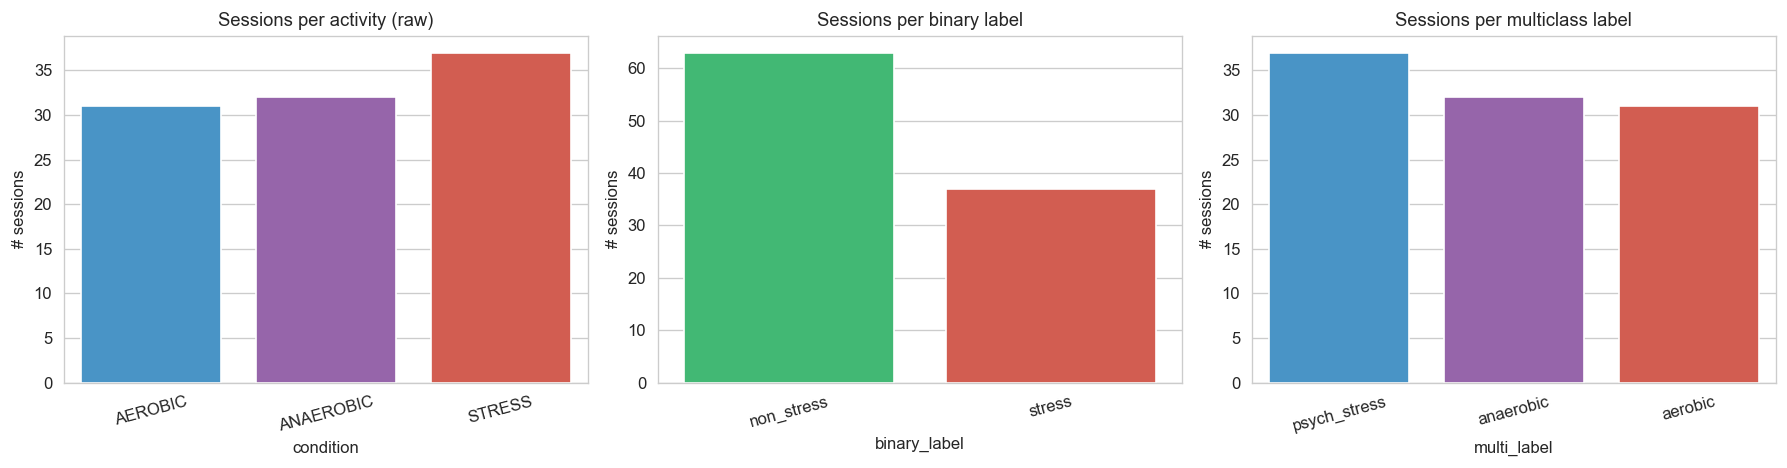

In [114]:
raw_counts = loaded_df["condition"].value_counts().sort_index()
print("Raw session counts per condition:")
print(raw_counts.to_string())

binary_counts = loaded_df["binary_label"].map(BINARY_NAMES).value_counts()
multi_counts  = loaded_df["multi_label"].map(MULTICLASS_NAMES).value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x=raw_counts.index, y=raw_counts.values, ax=axes[0],
            palette=["#3498db", "#9b59b6", "#e74c3c"])
axes[0].set_title("Sessions per activity (raw)")
axes[0].set_ylabel("# sessions")

sns.barplot(x=binary_counts.index, y=binary_counts.values, ax=axes[1],
            palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Sessions per binary label")
axes[1].set_ylabel("# sessions")

sns.barplot(x=multi_counts.index, y=multi_counts.values, ax=axes[2],
            palette=["#3498db", "#9b59b6", "#e74c3c"])
axes[2].set_title("Sessions per multiclass label")
axes[2].set_ylabel("# sessions")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "label_distribution_sessions.png", bbox_inches="tight")
plt.show()


## 6 — Exploratory Data Analysis

### 6.1  Per-session summary statistics

In [115]:
def signal_stats(sig: np.ndarray, name: str) -> dict:
    """Short stats summary for one channel."""
    if sig is None or len(sig) == 0:
        return {f"{name}_μ": np.nan, f"{name}_σ": np.nan, f"{name}_NaN%": np.nan}
    n_nan = np.isnan(sig).sum()
    sig_clean = sig[~np.isnan(sig)]
    return {
        f"{name}_μ":    float(np.mean(sig_clean)) if len(sig_clean) else np.nan,
        f"{name}_σ":    float(np.std(sig_clean))  if len(sig_clean) else np.nan,
        f"{name}_NaN%": 100 * n_nan / max(1, len(sig)),
    }


rows = []
for s in sessions:
    bvp  = s["BVP"]["data"]
    temp = s["TEMP"]["data"]
    acc_mag = np.linalg.norm(s["ACC"]["data"], axis=1)
    eda_data = s["EDA"]["data"] if s["EDA"] is not None else None

    row = {
        "subject":      s["subject"],
        "session_id":   s["session_id"],
        "condition":    s["condition"],
        "duration_min": s["duration_s"] / 60,
    }
    row.update(signal_stats(bvp,      "BVP"))
    row.update(signal_stats(temp,     "TEMP"))
    row.update(signal_stats(acc_mag,  "ACCmag"))
    row.update(signal_stats(eda_data, "EDA"))
    rows.append(row)

stats_df = pd.DataFrame(rows).round(3)
print(f"Mean session duration: {stats_df['duration_min'].mean():.1f} min "
      f"(min={stats_df['duration_min'].min():.1f}, max={stats_df['duration_min'].max():.1f})")
stats_df.head(10)


Mean session duration: 34.8 min (min=5.0, max=80.2)


,subject,session_id,condition,duration_min,BVP_μ,BVP_σ,BVP_NaN%,TEMP_μ,TEMP_σ,TEMP_NaN%,ACCmag_μ,ACCmag_σ,ACCmag_NaN%,EDA_μ,EDA_σ,EDA_NaN%
0,S01,S01,AEROBIC,34.003,-0.004,46.853,0.0,32.468,2.013,0.0,63.521,2.588,0.0,3.465,4.924,0.0
1,S02,S02,AEROBIC,33.960,0.003,48.570,0.0,32.778,0.719,0.0,63.863,1.874,0.0,22.775,6.985,0.0
2,S03,S03,AEROBIC,23.968,0.002,120.900,0.0,34.140,0.223,0.0,64.642,1.153,0.0,13.175,8.660,0.0
3,S04,S04,AEROBIC,34.003,0.005,125.028,0.0,32.626,1.440,0.0,64.344,3.810,0.0,21.884,17.733,0.0
4,S05,S05,AEROBIC,32.963,0.017,90.576,0.0,33.193,0.991,0.0,64.553,5.192,0.0,16.174,3.424,0.0
5,S06,S06,AEROBIC,34.435,-0.001,43.207,0.0,31.458,0.704,0.0,64.346,4.032,0.0,3.270,2.502,0.0
6,S07,S07,AEROBIC,27.993,0.003,107.266,0.0,211.937,5.771,0.0,64.216,1.571,0.0,6.061,3.381,0.0
7,S08,S08,AEROBIC,33.828,0.012,65.502,0.0,31.760,0.734,0.0,64.449,3.415,0.0,10.137,13.591,0.0
8,S09,S09,AEROBIC,33.960,-0.004,32.804,0.0,48.425,55.753,0.0,64.612,1.748,0.0,3.452,4.531,0.0
9,S10,S10,AEROBIC,33.965,0.005,77.970,0.0,34.622,0.427,0.0,62.621,4.047,0.0,22.510,11.203,0.0


### 6.2  Missing-value analysis

In [116]:
missing_summary = stats_df[[c for c in stats_df.columns if c.endswith("NaN%")]].agg(
    ["mean", "max"]
).round(3)
print("Per-channel NaN ratio across sessions (% of samples):")
print(missing_summary.to_string())


Per-channel NaN ratio across sessions (% of samples):
      BVP_NaN%  TEMP_NaN%  ACCmag_NaN%  EDA_NaN%
mean       0.0        0.0          0.0       0.0
max        0.0        0.0          0.0       0.0


### 6.3  Sensor distributions per condition

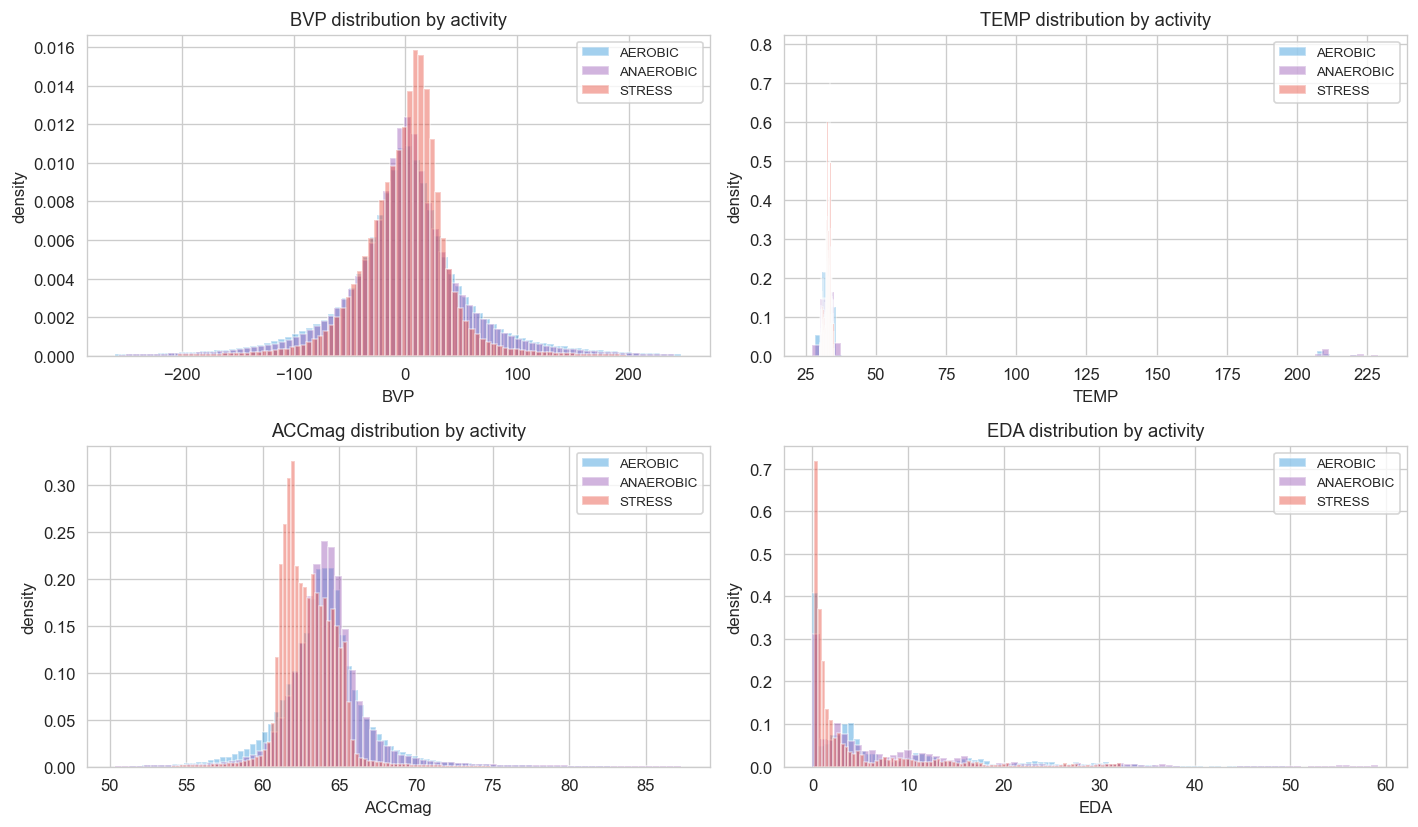

In [117]:
def gather_channel(cond: str, channel: str, max_sessions: int = 20) -> np.ndarray:
    """Concatenate raw values for a channel across (up to) N sessions of one condition."""
    out = []
    cnt = 0
    for s in sessions:
        if s["condition"] != cond or cnt >= max_sessions:
            continue
        if channel == "ACCmag":
            arr = np.linalg.norm(s["ACC"]["data"], axis=1)
        elif channel in ("EDA",) and s["EDA"] is None:
            continue
        else:
            arr = s[channel]["data"]
        out.append(arr[~np.isnan(arr)])
        cnt += 1
    return np.concatenate(out) if out else np.empty(0)


channels_to_plot = ["BVP", "TEMP", "ACCmag", "EDA"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
palette = {"AEROBIC": "#3498db", "ANAEROBIC": "#9b59b6", "STRESS": "#e74c3c"}

for ax, ch in zip(axes.flat, channels_to_plot):
    for cond in CONDITIONS:
        vals = gather_channel(cond, ch)
        if len(vals) == 0:
            continue
        # Trim to 0.5–99.5 percentile range for readable histograms
        lo, hi = np.percentile(vals, [0.5, 99.5])
        vals = vals[(vals >= lo) & (vals <= hi)]
        ax.hist(vals, bins=80, alpha=0.45, color=palette[cond], label=cond, density=True)
    ax.set_title(f"{ch} distribution by activity")
    ax.set_xlabel(ch)
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "sensor_distributions.png", bbox_inches="tight")
plt.show()


### 6.4  Inter-channel correlation (raw signals)

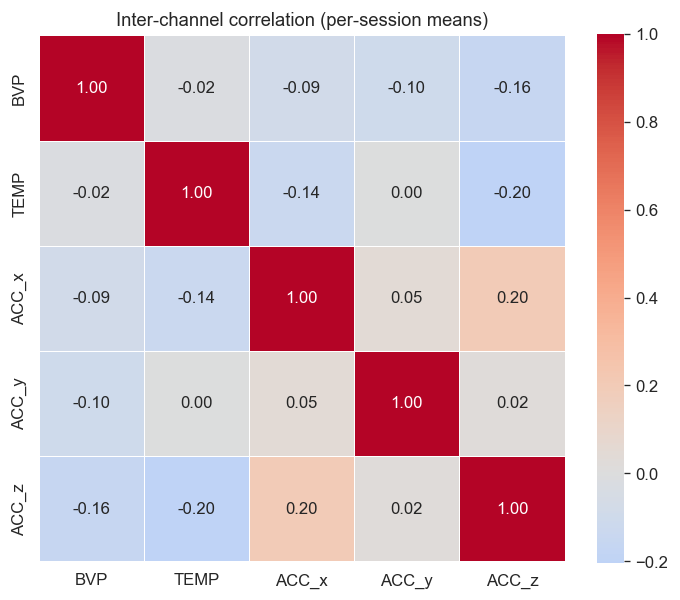

In [118]:
def session_means(s):
    """Per-session mean vector across the 5 modelling channels."""
    bvp_m = np.nanmean(s["BVP"]["data"])
    temp_m = np.nanmean(s["TEMP"]["data"])
    acc_m = np.nanmean(s["ACC"]["data"], axis=0)   # (3,)
    return [bvp_m, temp_m, acc_m[0], acc_m[1], acc_m[2]]

mean_mat = np.array([session_means(s) for s in sessions])
corr_df = pd.DataFrame(mean_mat, columns=APPLE_WATCH_CHANNELS).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Inter-channel correlation (per-session means)")
plt.tight_layout()
plt.savefig(OUT_DIR / "channel_correlation.png", bbox_inches="tight")
plt.show()


### 6.5  Time-series snapshot — one session per condition

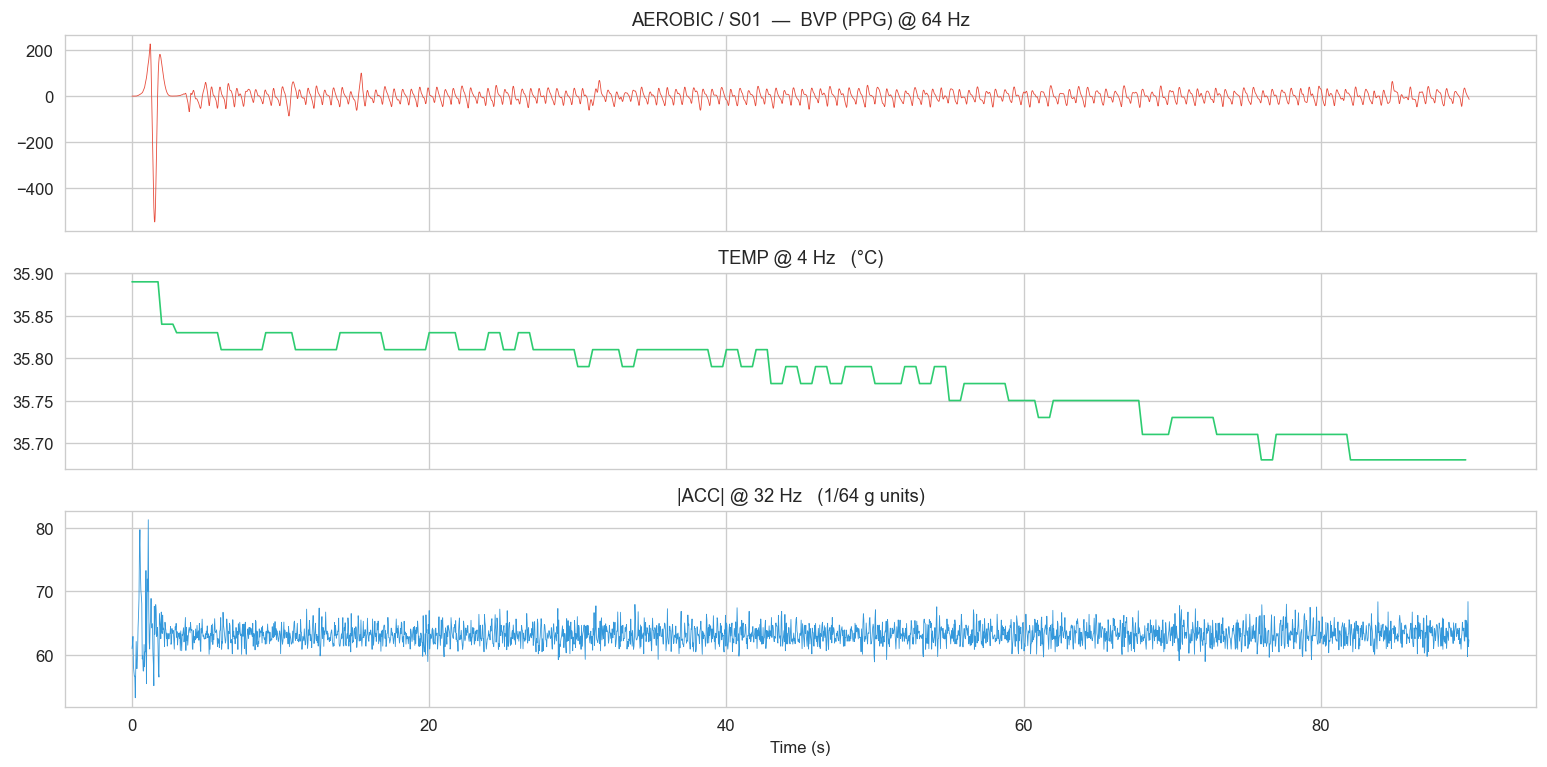

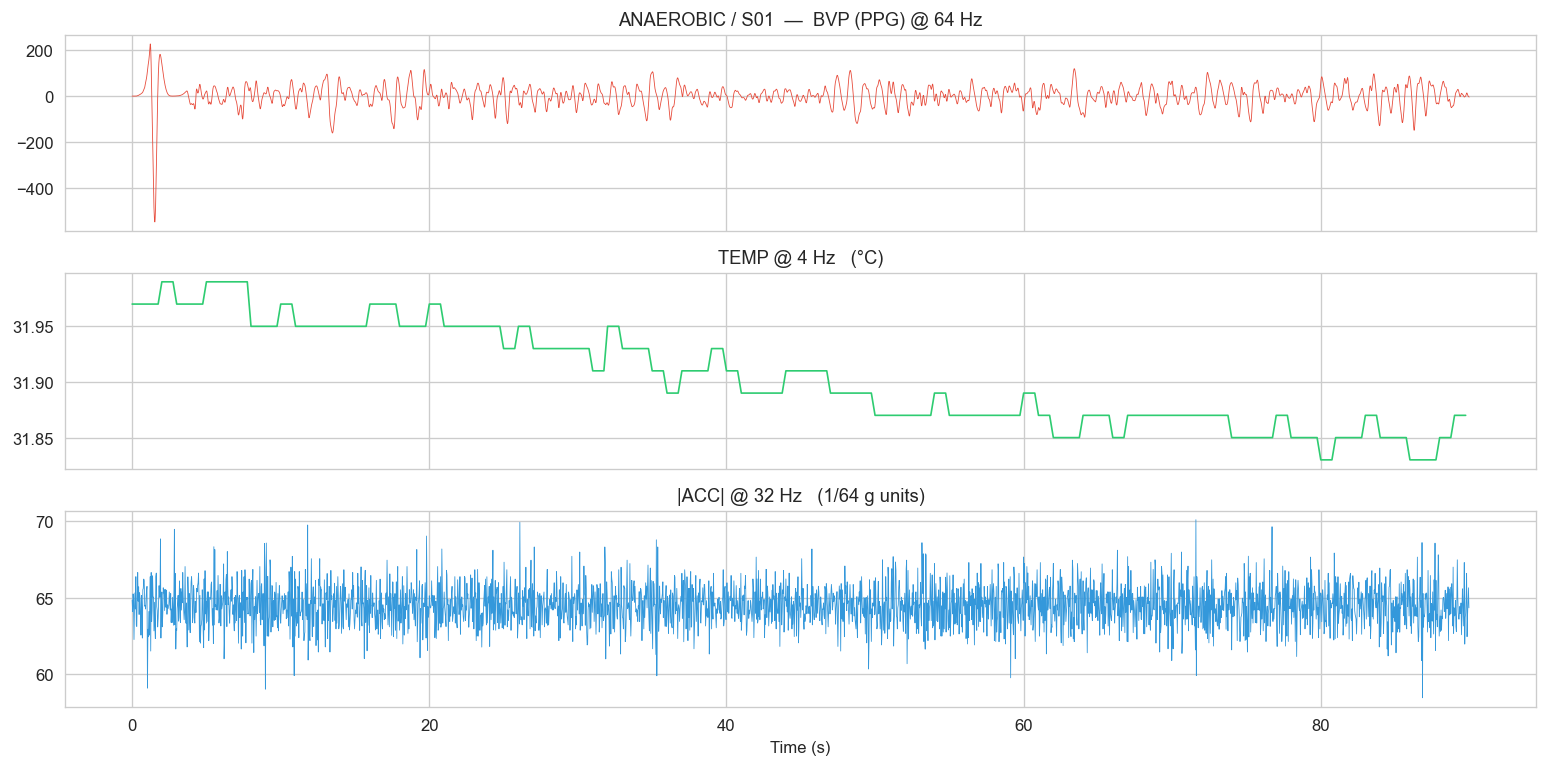

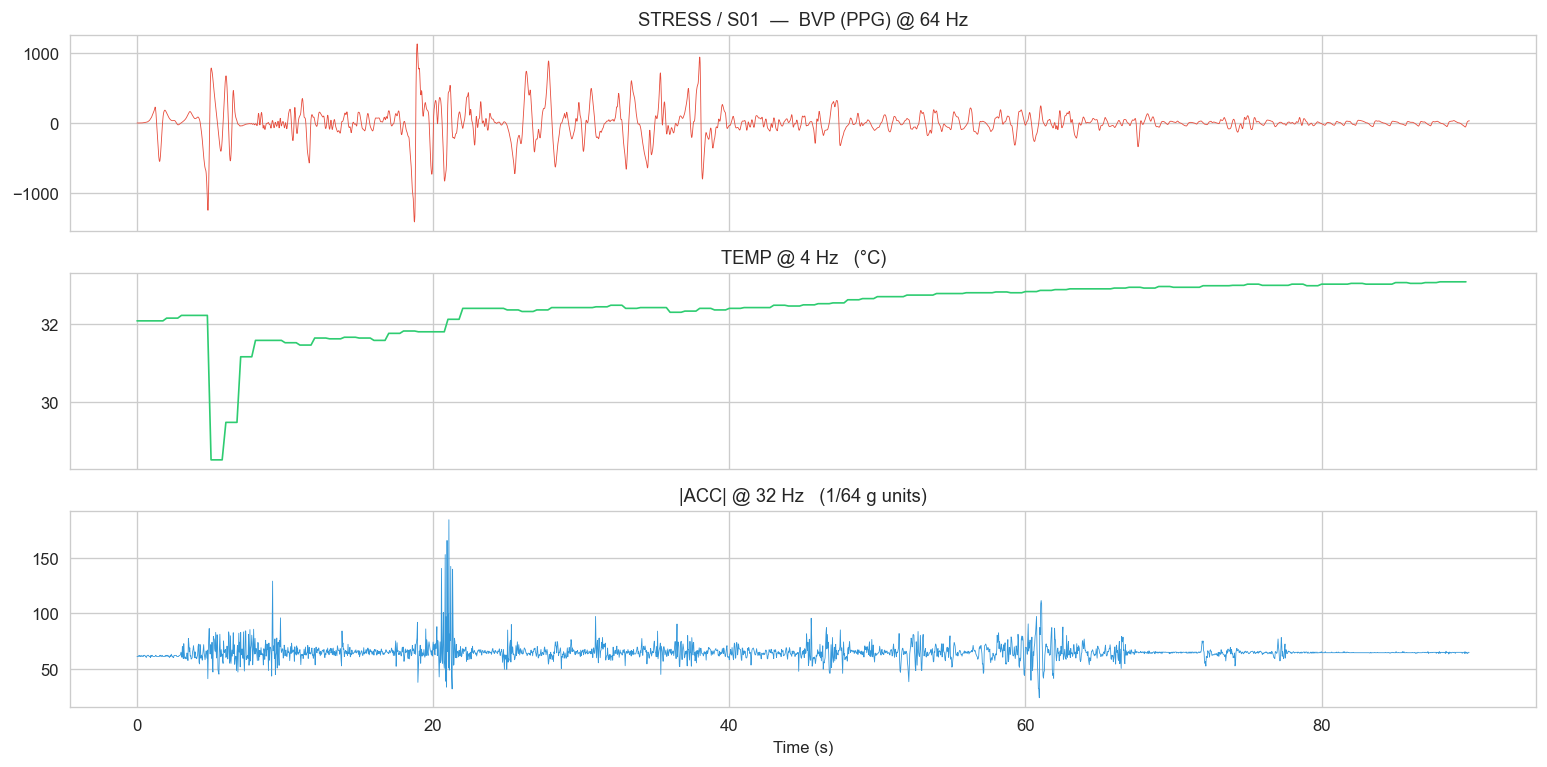

In [119]:
def plot_session_snapshot(sess, seconds: int = 120):
    """Plot the first ``seconds`` of a session for the 3 modelling modalities."""
    fig, axes = plt.subplots(3, 1, figsize=(13, 6.5), sharex=True)
    sid = sess["session_id"]; cond = sess["condition"]

    bvp = sess["BVP"]["data"]; bvp_fs = sess["BVP"]["fs"]
    n_bvp = int(seconds * bvp_fs)
    axes[0].plot(np.arange(min(n_bvp, len(bvp))) / bvp_fs,
                 bvp[:n_bvp], color="#e74c3c", linewidth=0.5)
    axes[0].set_title(f"{cond} / {sid}  —  BVP (PPG) @ {bvp_fs:.0f} Hz")

    temp = sess["TEMP"]["data"]; temp_fs = sess["TEMP"]["fs"]
    n_temp = int(seconds * temp_fs)
    axes[1].plot(np.arange(min(n_temp, len(temp))) / temp_fs,
                 temp[:n_temp], color="#2ecc71", linewidth=1.0)
    axes[1].set_title(f"TEMP @ {temp_fs:.0f} Hz   (°C)")

    acc = sess["ACC"]["data"]; acc_fs = sess["ACC"]["fs"]
    n_acc = int(seconds * acc_fs)
    axes[2].plot(np.arange(min(n_acc, len(acc))) / acc_fs,
                 np.linalg.norm(acc[:n_acc], axis=1), color="#3498db", linewidth=0.5)
    axes[2].set_title(f"|ACC| @ {acc_fs:.0f} Hz   (1/64 g units)")
    axes[2].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()


for cond in CONDITIONS:
    sess = next((s for s in sessions if s["condition"] == cond), None)
    if sess is not None:
        plot_session_snapshot(sess, seconds=90)


### 6.6  Subject × condition coverage

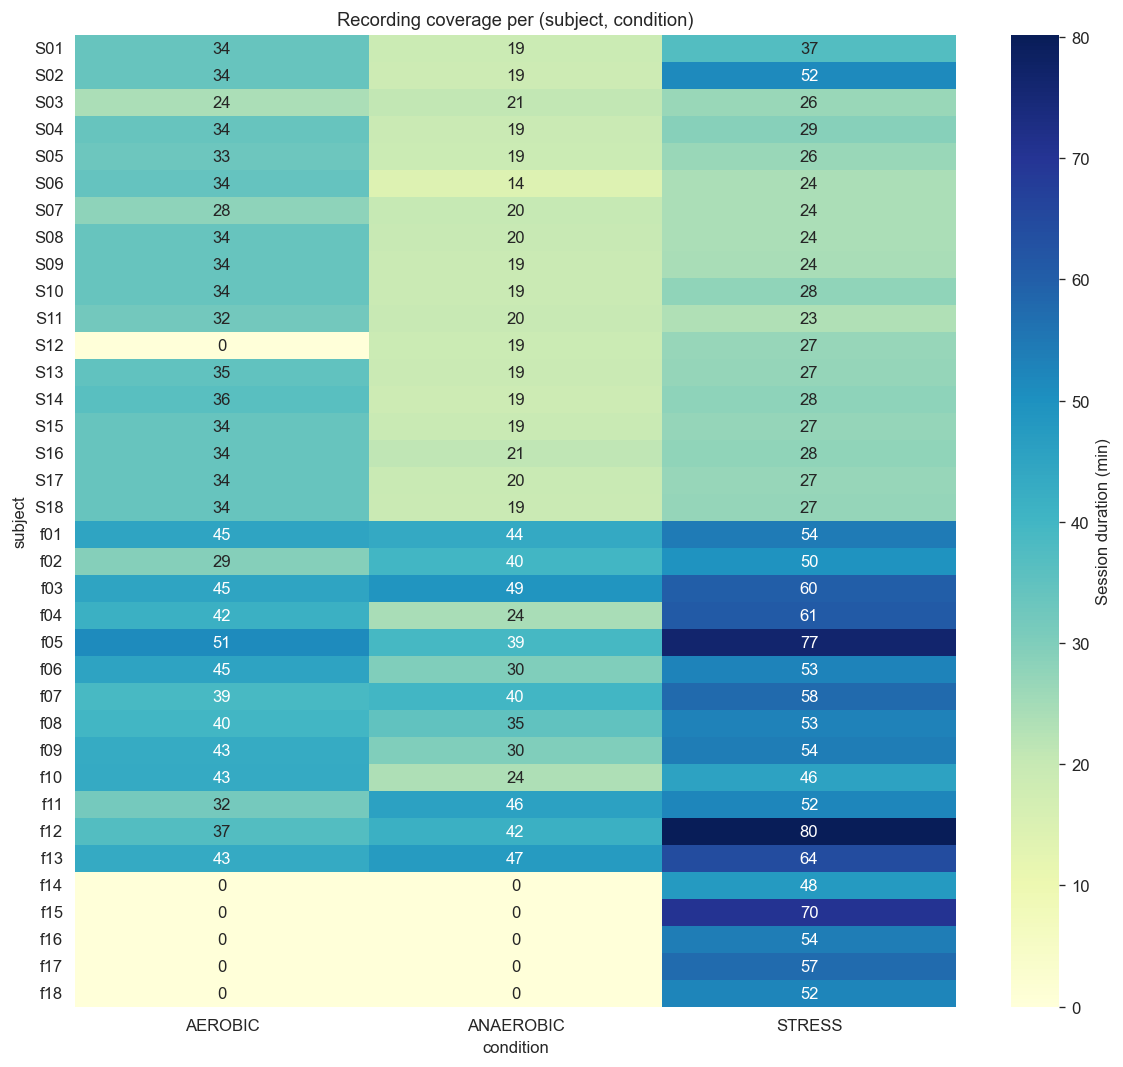

In [120]:
pivot_dur = loaded_df.pivot_table(
    index="subject", columns="condition", values="duration_min",
    aggfunc="sum", fill_value=0,
)
plt.figure(figsize=(10, max(4, 0.25 * len(pivot_dur))))
sns.heatmap(pivot_dur, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "Session duration (min)"})
plt.title("Recording coverage per (subject, condition)")
plt.tight_layout()
plt.savefig(OUT_DIR / "coverage_heatmap.png", bbox_inches="tight")
plt.show()


## 7 — Preprocessing Pipeline

| Step | Detail |
|---|---|
| **Unit conversion** | ACC from 1/64 g → g |
| **Bandpass filter** | BVP: 4th-order Butterworth 0.5–8 Hz |
| **Resample** | All channels → 32 Hz (common clock) |
| **Per-session Z-score** | One mean/std per channel, per session |
| **Window** | 30 s (960 samples) / 15 s overlap |
| **Window labels** | Inherit the session-level label (no within-session transitions) |
| **NaN handling** | Drop windows containing NaNs after resampling |

In [121]:
def bandpass(sig, low, high, sr, order=4):
    nyq = sr / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)


def resample_to(sig, orig_sr, target_sr):
    if abs(orig_sr - target_sr) < 1e-6:
        return sig.astype(np.float32)
    new_len = int(round(len(sig) * target_sr / orig_sr))
    if sig.ndim == 1:
        return resample(sig, new_len).astype(np.float32)
    return np.column_stack([resample(sig[:, c], new_len) for c in range(sig.shape[1])]
                          ).astype(np.float32)


def make_windows(data, label, win_len, step):
    """Slide fixed-length windows over a session and tag each with ``label``."""
    if len(data) < win_len:
        return np.empty((0, win_len, data.shape[1]), dtype=np.float32),                np.empty((0,), dtype=np.int64)
    starts = range(0, len(data) - win_len + 1, step)
    X = np.stack([data[s:s + win_len] for s in starts]).astype(np.float32)
    # Drop any window that contains NaNs (defensive — should be rare after fillna)
    keep = ~np.isnan(X).any(axis=(1, 2))
    return X[keep], np.full(int(keep.sum()), label, dtype=np.int64)


def preprocess_session(sess) -> tuple[np.ndarray, np.ndarray]:
    """Return (X_windows, y_windows) for one session."""
    bvp_fs  = sess["BVP"]["fs"];  bvp  = sess["BVP"]["data"]
    temp_fs = sess["TEMP"]["fs"]; temp = sess["TEMP"]["data"]
    acc_fs  = sess["ACC"]["fs"];  acc  = sess["ACC"]["data"]

    # Fill small gaps so the bandpass / resample don't blow up
    bvp  = pd.Series(bvp).interpolate().bfill().ffill().to_numpy(dtype=np.float32)
    temp = pd.Series(temp).interpolate().bfill().ffill().to_numpy(dtype=np.float32)
    acc  = pd.DataFrame(acc).interpolate().bfill().ffill().to_numpy(dtype=np.float32)

    # 1. Unit conversion: ACC 1/64 g → g
    acc_g = acc / 64.0

    # 2. Bandpass BVP at native fs
    if len(bvp) >= 33:                       # filtfilt needs >~3·order samples
        bvp = bandpass(bvp, BVP_LOW_HZ, BVP_HIGH_HZ, sr=bvp_fs)

    # 3. Resample to TARGET_SR
    bvp_32  = resample_to(bvp,   bvp_fs,  TARGET_SR)
    temp_32 = resample_to(temp,  temp_fs, TARGET_SR)
    acc_32  = resample_to(acc_g, acc_fs,  TARGET_SR)

    # 4. Trim to common length
    n = min(len(bvp_32), len(temp_32), len(acc_32))
    if n < WINDOW_LEN:
        return np.empty((0, WINDOW_LEN, N_CHANNELS), dtype=np.float32),                np.empty((0,), dtype=np.int64)

    data = np.column_stack([bvp_32[:n], temp_32[:n], acc_32[:n]])

    # 5. Per-session Z-score
    mu  = np.nanmean(data, axis=0)
    std = np.nanstd(data,  axis=0) + 1e-8
    data = ((data - mu) / std).astype(np.float32)

    # 6. Window
    return make_windows(data, sess["binary_label"], WINDOW_LEN, STEP_LEN)


print("Preprocessing helpers defined ✓")


Preprocessing helpers defined ✓


In [122]:
all_X, all_y, all_subj, all_cond = [], [], [], []

for s in sessions:
    Xs, ys = preprocess_session(s)
    if len(Xs) == 0:
        print(f"  ⚠  {s['condition']}/{s['session_id']}: 0 windows after preprocessing")
        continue
    all_X.append(Xs)
    all_y.append(ys)
    all_subj.extend([s["subject"]]   * len(ys))
    all_cond.extend([s["condition"]] * len(ys))

X    = np.concatenate(all_X, axis=0)
y    = np.concatenate(all_y, axis=0)
subj = np.array(all_subj)
cond = np.array(all_cond)

print(f"\n{'═'*55}")
print(f"  Total windows : {len(y)}")
print(f"  X shape       : {X.shape}   ({X.nbytes/1e6:.1f} MB)")
print(f"  Channels      : {APPLE_WATCH_CHANNELS}")
print(f"  non_stress (0): {(y == 0).sum()}")
print(f"  stress     (1): {(y == 1).sum()}")
print(f"  ratio         : {(y == 0).sum()/len(y):.1%} / {(y == 1).sum()/len(y):.1%}")
print(f"{'═'*55}")



═══════════════════════════════════════════════════════
  Total windows : 13775
  X shape       : (13775, 960, 5)   (264.5 MB)
  Channels      : ['BVP', 'TEMP', 'ACC_x', 'ACC_y', 'ACC_z']
  non_stress (0): 7628
  stress     (1): 6147
  ratio         : 55.4% / 44.6%
═══════════════════════════════════════════════════════


### 7.1  Preprocessed window comparison (one example per class)

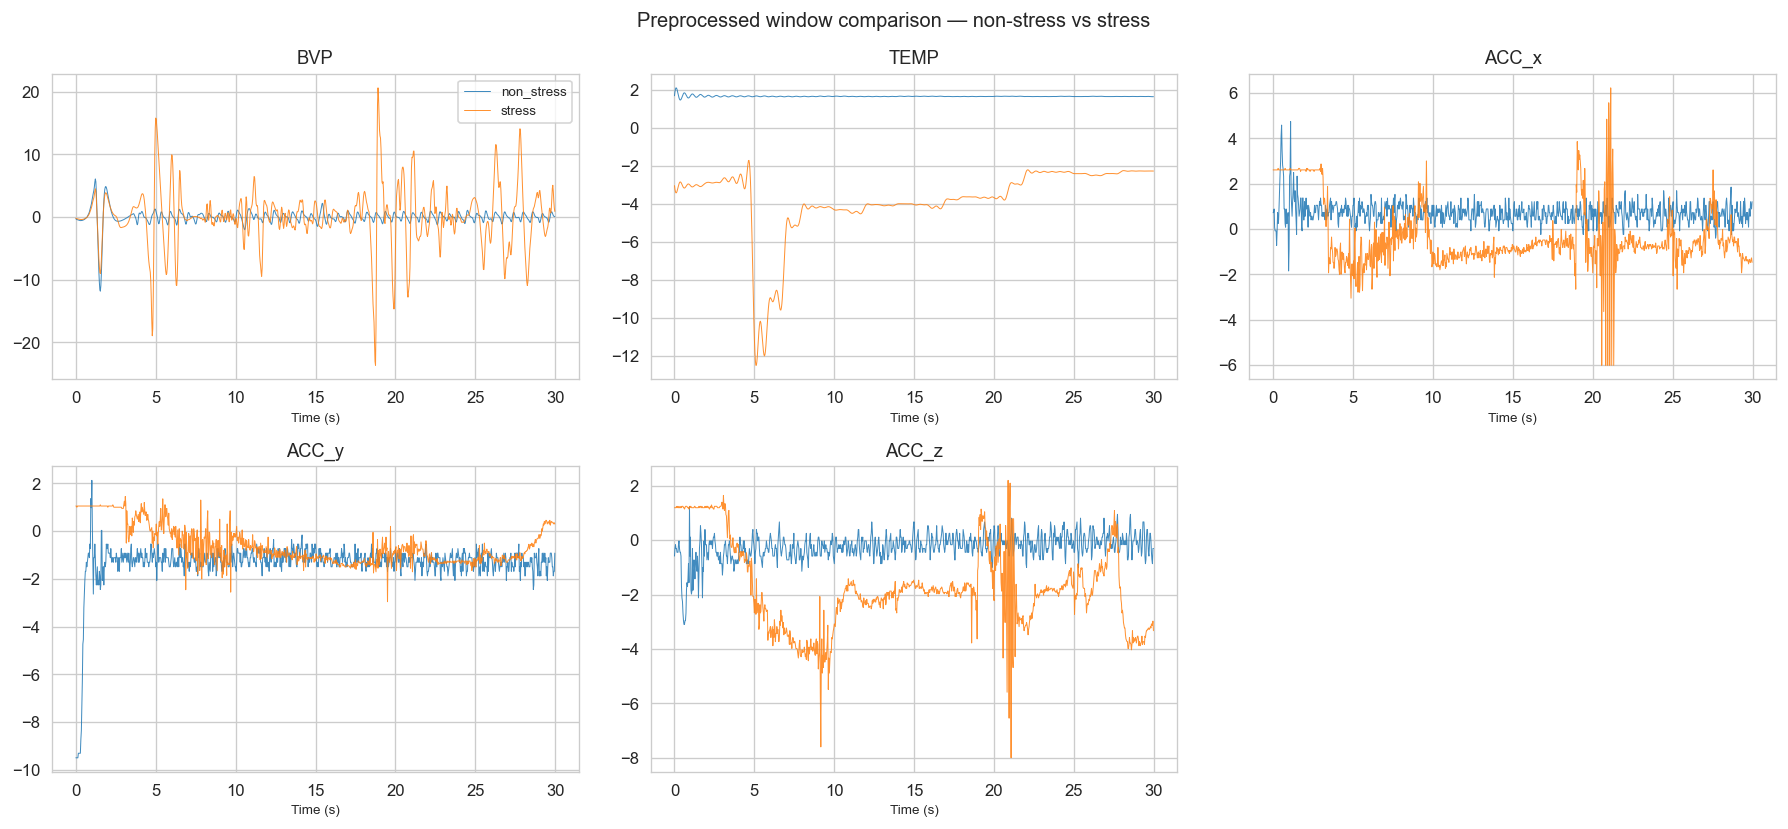

In [123]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
t = np.arange(WINDOW_LEN) / TARGET_SR

idx_b = np.where(y == 0)[0][0]
idx_s = np.where(y == 1)[0][0]

for i, ax in enumerate(axes.flat[:N_CHANNELS]):
    ax.plot(t, X[idx_b, :, i], label="non_stress", linewidth=0.6, alpha=0.85)
    ax.plot(t, X[idx_s, :, i], label="stress",     linewidth=0.6, alpha=0.85)
    ax.set_title(APPLE_WATCH_CHANNELS[i])
    ax.set_xlabel("Time (s)", fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)
axes.flat[-1].axis("off")
plt.suptitle("Preprocessed window comparison — non-stress vs stress")
plt.tight_layout()
plt.savefig(OUT_DIR / "window_comparison.png", bbox_inches="tight")
plt.show()


### 7.2  Inter-channel correlation (windowed, post-preprocessing)

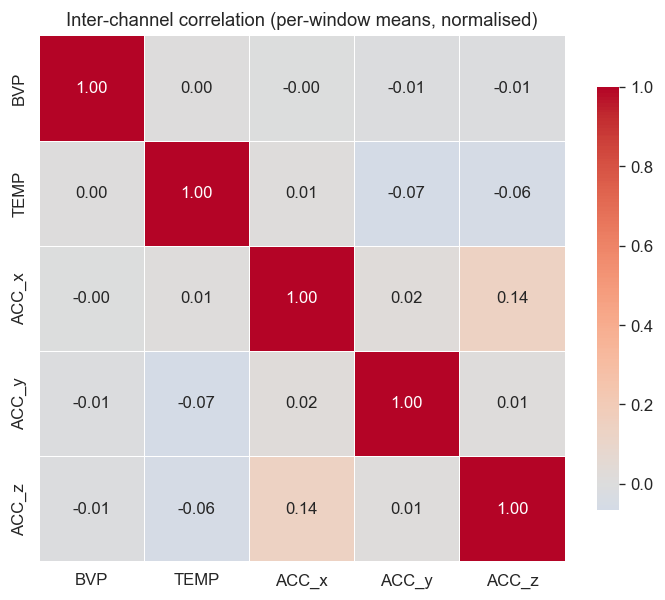

In [124]:
X_flat = X.mean(axis=1)
corr = pd.DataFrame(X_flat, columns=APPLE_WATCH_CHANNELS).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Inter-channel correlation (per-window means, normalised)")
plt.tight_layout()
plt.savefig(OUT_DIR / "channel_correlation_windows.png", bbox_inches="tight")
plt.show()


## 8 — Feature Engineering

The original WESAD notebook feeds the **raw windowed waveforms** directly to
EdgeStressNet / PatchTST — it doesn't run a hand-crafted feature path. We
preserve that behaviour for the deep-learning models and additionally compute
a small statistical feature table that's useful for sanity checks (e.g. a
quick logistic-regression baseline) and for any downstream analysis.

In [125]:
def stat_features_window(win: np.ndarray) -> np.ndarray:
    """Compute per-channel statistical features for one (T, C) window."""
    feats = []
    for c in range(win.shape[1]):
        v = win[:, c]
        feats.extend([
            v.mean(), v.std(),
            v.min(), v.max(), np.median(v),
            sp_stats.skew(v),  sp_stats.kurtosis(v),
            np.percentile(v, 25), np.percentile(v, 75),
        ])
    return np.asarray(feats, dtype=np.float32)


_FEAT_NAMES = ["mean", "std", "min", "max", "median", "skew", "kurt", "p25", "p75"]
FEATURE_NAMES = [f"{ch}_{f}" for ch in APPLE_WATCH_CHANNELS for f in _FEAT_NAMES]

# Compute on the full set of preprocessed windows (vectorised loop)
features = np.stack([stat_features_window(w) for w in X])
feat_df = pd.DataFrame(features, columns=FEATURE_NAMES)
feat_df["label"]   = y
feat_df["subject"] = subj
feat_df["cond"]    = cond
print(f"Feature table: {feat_df.shape}   ({len(FEATURE_NAMES)} stats × 5 channels)")
feat_df.head()


Feature table: (13775, 48)   (45 stats × 5 channels)


,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_median,BVP_skew,BVP_kurt,BVP_p25,BVP_p75,TEMP_mean,...,ACC_z_min,ACC_z_max,ACC_z_median,ACC_z_skew,ACC_z_kurt,ACC_z_p25,ACC_z_p75,label,subject,cond
0,0.000167,1.242608,-11.824256,6.073190,-0.010413,-3.249577,35.619587,-0.419460,0.456008,1.667361,...,-3.093412,1.232372,-0.163042,-1.622694,7.362410,-0.442125,-0.023501,0,S01,AEROBIC
1,-0.002997,0.539421,-1.487454,2.184167,0.015647,0.018697,-0.077510,-0.373914,0.384309,1.658543,...,-1.000291,1.092831,-0.023501,0.131567,0.056252,-0.302583,0.255582,0,S01,AEROBIC
2,-0.002762,0.513839,-1.407650,1.367646,0.040082,-0.206723,-0.639256,-0.368167,0.380824,1.647629,...,-1.000291,1.371914,0.116041,0.115220,0.146791,-0.023501,0.395124,0,S01,AEROBIC
3,0.004184,0.499476,-1.292276,1.047357,0.030510,-0.241194,-0.671636,-0.358062,0.381993,1.631031,...,-0.860749,1.511455,0.255582,0.193377,0.164680,0.116041,0.534665,0,S01,AEROBIC
4,0.002954,0.493787,-1.167167,1.329804,0.030510,-0.155269,-0.667535,-0.347936,0.375830,1.610619,...,-0.860749,1.511455,0.395124,0.167253,0.222215,0.116041,0.674207,0,S01,AEROBIC


## 9 — Class-Imbalance Handling

In [126]:
n0, n1 = (y == 0).sum(), (y == 1).sum()
w0 = len(y) / (2 * n0)
w1 = len(y) / (2 * n1)
print(f"Class weights for CrossEntropy:  w_non_stress = {w0:.3f},  w_stress = {w1:.3f}")
print(f"  (non_stress dominates by {n0/n1:.2f}× → weights compensate)")


Class weights for CrossEntropy:  w_non_stress = 0.903,  w_stress = 1.120
  (non_stress dominates by 1.24× → weights compensate)


## 10 — Subject-Independent Split

We split **on the base subject id** (so all sessions of S03 stay in the same
fold). Because each base subject potentially contributes 3 sessions
(AEROBIC / ANAEROBIC / STRESS), grouping by base id is the only way to
prevent leakage of within-subject signal between train and test.

In [127]:
unique_subjects = sorted(set(subj))
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(unique_subjects)

n_total = len(shuffled)
n_test  = max(1, int(round(0.20 * n_total)))
n_val   = max(1, int(round(0.20 * n_total)))

test_subj  = set(shuffled[:n_test])
val_subj   = set(shuffled[n_test : n_test + n_val])
train_subj = set(shuffled[n_test + n_val :])

print(f"Train subjects ({len(train_subj)}): {sorted(train_subj)}")
print(f"Val   subjects ({len(val_subj)}):   {sorted(val_subj)}")
print(f"Test  subjects ({len(test_subj)}):  {sorted(test_subj)}")


def split_by_subjects(X, y, subj, group):
    mask = np.isin(subj, list(group))
    return X[mask], y[mask]


X_train, y_train = split_by_subjects(X, y, subj, train_subj)
X_val,   y_val   = split_by_subjects(X, y, subj, val_subj)
X_test,  y_test  = split_by_subjects(X, y, subj, test_subj)

# Fallback safety: if a fold ends up with one class only, fall back to a
# stratified per-window split so training can still proceed.
def _has_two_classes(yy): return len(np.unique(yy)) > 1
if not all(map(_has_two_classes, [y_train, y_val, y_test])):
    print("\n⚠  Subject-wise split produced a single-class fold — falling back to "
          "stratified per-window split.")
    from sklearn.model_selection import train_test_split
    Xtv, X_test, ytv, y_test = train_test_split(X, y, test_size=0.2, stratify=y,
                                                random_state=SEED)
    X_train, X_val, y_train, y_val = train_test_split(Xtv, ytv, test_size=0.25,
                                                      stratify=ytv, random_state=SEED)

for name, Xs, ys in [("Train", X_train, y_train),
                     ("Val",   X_val,   y_val),
                     ("Test",  X_test,  y_test)]:
    n_b = int((ys == 0).sum()); n_s = int((ys == 1).sum())
    print(f"{name:5s}  →  {len(ys):5d} windows  |  non_stress={n_b}  stress={n_s}")


Train subjects (22): [np.str_('S01'), np.str_('S02'), np.str_('S03'), np.str_('S04'), np.str_('S07'), np.str_('S09'), np.str_('S10'), np.str_('S12'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S18'), np.str_('f02'), np.str_('f04'), np.str_('f07'), np.str_('f11'), np.str_('f12'), np.str_('f13'), np.str_('f14'), np.str_('f17')]
Val   subjects (7):   [np.str_('S08'), np.str_('S11'), np.str_('f03'), np.str_('f05'), np.str_('f08'), np.str_('f15'), np.str_('f16')]
Test  subjects (7):  [np.str_('S05'), np.str_('S06'), np.str_('f01'), np.str_('f06'), np.str_('f09'), np.str_('f10'), np.str_('f18')]
Train  →   8075 windows  |  non_stress=4589  stress=3486
Val    →   2876 windows  |  non_stress=1442  stress=1434
Test   →   2824 windows  |  non_stress=1597  stress=1227


## 11 — PyTorch Datasets & Loaders

In [128]:
def to_tensors(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)   # (N, C, T)
    yt = torch.tensor(y, dtype=torch.long)
    return Xt, yt


X_tr, y_tr = to_tensors(X_train, y_train)
X_v,  y_v  = to_tensors(X_val,   y_val)
X_te, y_te = to_tensors(X_test,  y_test)

train_ds = TensorDataset(X_tr, y_tr)
val_ds   = TensorDataset(X_v,  y_v)
test_ds  = TensorDataset(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=(len(train_ds) > BATCH_SIZE))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}")
print(f"Tensor shape  — X_tr: {X_tr.shape}  (batch, {N_CHANNELS} ch, {WINDOW_LEN} samples)")


Train batches: 126  |  Val: 45  |  Test: 45
Tensor shape  — X_tr: torch.Size([8075, 5, 960])  (batch, 5 ch, 960 samples)


## 12 — Model A: EdgeStressNet (1D-DSC + BiGRU)

Lightweight architecture replicated verbatim from the Apple-Watch build:
depthwise-separable 1-D convolutions, bidirectional GRU, attention pooling
and a linear head. Same input shape `(B, 5, 960)`.

In [129]:
class DepthwiseSepConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, padding="same"):
        super().__init__()
        self.depthwise = nn.Conv1d(in_ch, in_ch, kernel_size,
                                   padding=padding, groups=in_ch, bias=False)
        self.pointwise = nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pointwise(self.depthwise(x))))


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)


class EdgeStressNet(nn.Module):
    """5-channel × 960-sample → 2-class logits. Identical to apple-watch build."""
    def __init__(self, in_channels=5, gru_hidden=48, n_classes=2, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            DepthwiseSepConv1d(in_channels, 32, 7),
            nn.MaxPool1d(2), nn.Dropout(dropout),
            DepthwiseSepConv1d(32, 64, 5),
            nn.MaxPool1d(2), nn.Dropout(dropout),
            DepthwiseSepConv1d(64, 64, 3),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.gru = nn.GRU(64, gru_hidden, num_layers=1,
                          batch_first=True, bidirectional=True)
        self.attn_pool = AttentionPool(gru_hidden * 2)
        self.head = nn.Sequential(
            nn.LayerNorm(gru_hidden * 2),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden * 2, n_classes),
        )

    def forward(self, x):
        h = self.conv(x).permute(0, 2, 1)
        h, _ = self.gru(h)
        return self.head(self.attn_pool(h))


model_a = EdgeStressNet(in_channels=N_CHANNELS).to(DEVICE)
n_params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)

print(f"Model A (EdgeStressNet)")
print(f"  Parameters : {n_params_a:,}")
print(f"  Size (est) : {n_params_a * 4 / 1024:.1f} KB (float32)")

dummy = torch.randn(2, N_CHANNELS, WINDOW_LEN).to(DEVICE)
print(f"  Output     : {model_a(dummy).shape}")


Model A (EdgeStressNet)
  Parameters : 40,326
  Size (est) : 157.5 KB (float32)
  Output     : torch.Size([2, 2])


## 13 — Model B: PatchTST (Transformer Baseline)

In [130]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, d_model, seq_len, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = seq_len // patch_size
        self.proj       = nn.Linear(patch_size, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        B, T = x.shape
        x = x[:, : self.n_patches * self.patch_size]
        x = x.reshape(B, self.n_patches, self.patch_size)
        return self.dropout(self.proj(x) + self.pos_embed)


class PatchTST(nn.Module):
    def __init__(self, in_channels=5, seq_len=960, patch_size=30,
                 d_model=64, n_heads=4, n_layers=3, d_ff=128,
                 dropout=0.2, n_classes=2):
        super().__init__()
        self.in_channels = in_channels
        self.patch_embeds = nn.ModuleList([
            PatchEmbedding(patch_size, d_model, seq_len, dropout)
            for _ in range(in_channels)
        ])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model * in_channels),
            nn.Dropout(dropout),
            nn.Linear(d_model * in_channels, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        reps = []
        for i in range(self.in_channels):
            tok = self.patch_embeds[i](x[:, i, :])
            reps.append(self.encoder(tok).mean(dim=1))
        return self.head(torch.cat(reps, dim=-1))


model_b = PatchTST(in_channels=N_CHANNELS, seq_len=WINDOW_LEN).to(DEVICE)
n_params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)

print(f"Model B (PatchTST)")
print(f"  Parameters : {n_params_b:,}")
print(f"  Size (est) : {n_params_b * 4 / 1024:.1f} KB (float32)")
print(f"  Output     : {model_b(dummy).shape}")
print(f"\nParam ratio  : PatchTST is {n_params_b / n_params_a:.1f}× larger than EdgeStressNet")


Model B (PatchTST)
  Parameters : 141,890
  Size (est) : 554.3 KB (float32)
  Output     : torch.Size([2, 2])

Param ratio  : PatchTST is 3.5× larger than EdgeStressNet


## 14 — Training Engine

In [131]:
class EarlyStopping:
    def __init__(self, patience=10, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.best_state = None

    def step(self, metric, model):
        improved = (metric > self.best) if self.mode == "max" else (metric < self.best)
        if improved:
            self.best = metric
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=DEVICE.type,
                                enabled=(DEVICE.type == "cuda")):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * len(yb)
        n += len(yb)
    return total_loss / max(1, n)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "y_true": y_true, "y_prob": y_prob, "y_pred": y_pred,
        "acc":   accuracy_score(y_true, y_pred),
        "f1":    f1_score(y_true, y_pred, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "prec":  precision_score(y_true, y_pred, zero_division=0),
        "rec":   recall_score(y_true, y_pred, zero_division=0),
    }


def train_model(model, name, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    print(f"\n{'═'*60}")
    print(f"  Training: {name}")
    print(f"{'═'*60}")

    weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    stopper   = EarlyStopping(patience=patience, mode="max")

    history = {"epoch": [], "train_loss": [], "val_acc": [], "val_f1": [], "val_auroc": []}
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        scheduler.step()
        m = evaluate(model, val_loader)
        elapsed = time.time() - t0

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(m["acc"])
        history["val_f1"].append(m["f1"])
        history["val_auroc"].append(m["auroc"] if not np.isnan(m["auroc"]) else 0)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  |  loss={train_loss:.4f}  "
                  f"val_acc={m['acc']:.3f}  val_f1={m['f1']:.3f}  "
                  f"val_auroc={m['auroc']:.3f}  ({elapsed:.1f}s)")

        # Track AUROC for early stopping; fall back to F1 if AUROC undefined
        guide = m["auroc"] if not np.isnan(m["auroc"]) else m["f1"]
        if stopper.step(guide, model):
            print(f"  → Early stop at epoch {epoch}  (best={stopper.best:.4f})")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)
    return pd.DataFrame(history)


print("Training engine ready ✓")


Training engine ready ✓


In [132]:
history_a = train_model(model_a, "Model A — EdgeStressNet (Wearable_Dataset)")


════════════════════════════════════════════════════════════
  Training: Model A — EdgeStressNet (Wearable_Dataset)
════════════════════════════════════════════════════════════
  Epoch   1/40  |  loss=0.4882  val_acc=0.847  val_f1=0.854  val_auroc=0.935  (38.9s)
  Epoch   5/40  |  loss=0.2061  val_acc=0.870  val_f1=0.878  val_auroc=0.966  (41.1s)
  Epoch  10/40  |  loss=0.1939  val_acc=0.886  val_f1=0.886  val_auroc=0.964  (40.8s)
  Epoch  15/40  |  loss=0.1676  val_acc=0.886  val_f1=0.889  val_auroc=0.967  (41.0s)
  → Early stop at epoch 16  (best=0.9688)


In [133]:
history_b = train_model(model_b, "Model B — PatchTST (Wearable_Dataset)")


════════════════════════════════════════════════════════════
  Training: Model B — PatchTST (Wearable_Dataset)
════════════════════════════════════════════════════════════
  Epoch   1/40  |  loss=0.3887  val_acc=0.789  val_f1=0.822  val_auroc=0.947  (14.7s)
  Epoch   5/40  |  loss=0.1593  val_acc=0.866  val_f1=0.876  val_auroc=0.957  (14.6s)
  Epoch  10/40  |  loss=0.1085  val_acc=0.857  val_f1=0.865  val_auroc=0.942  (15.0s)
  → Early stop at epoch 12  (best=0.9600)


### 14.1  Training curves

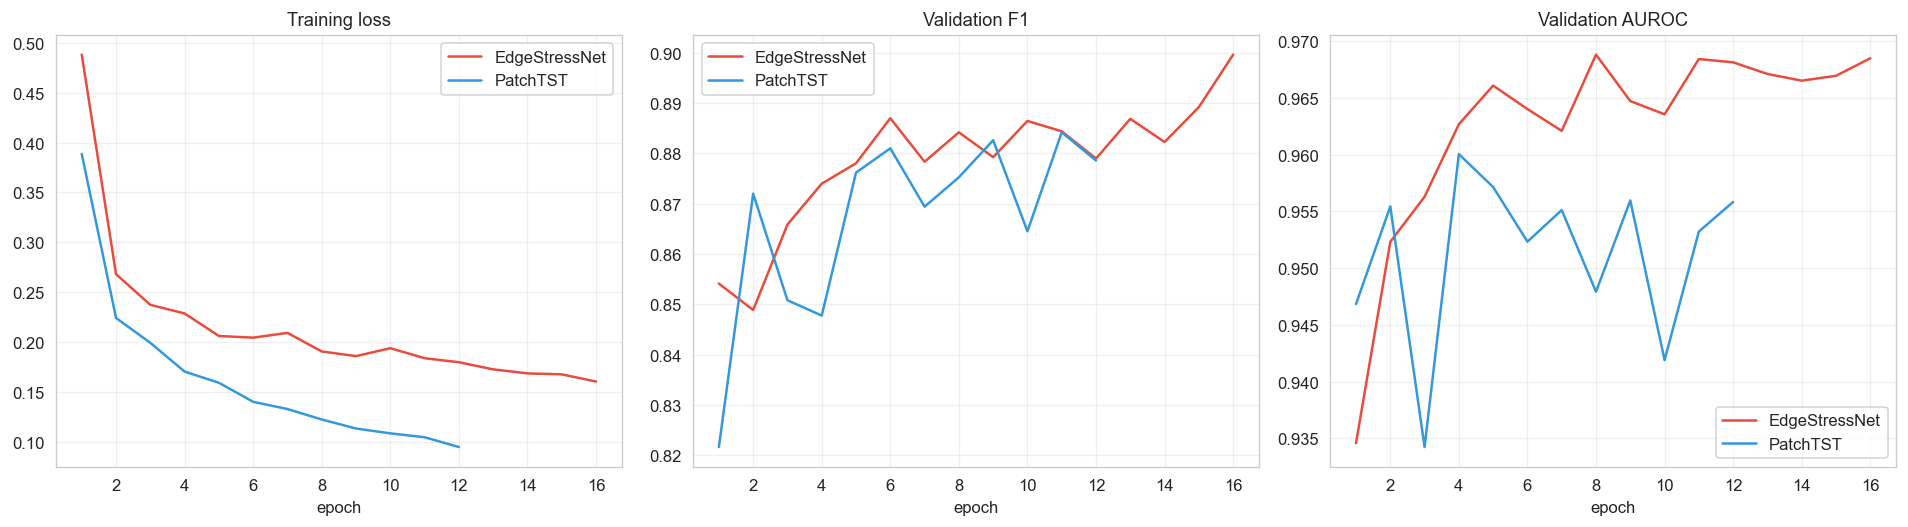

In [134]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for hist, name, color in [(history_a, "EdgeStressNet", "#e74c3c"),
                          (history_b, "PatchTST",       "#3498db")]:
    axes[0].plot(hist["epoch"], hist["train_loss"], label=name, color=color)
    axes[1].plot(hist["epoch"], hist["val_f1"],     label=name, color=color)
    axes[2].plot(hist["epoch"], hist["val_auroc"],  label=name, color=color)

axes[0].set_title("Training loss");  axes[0].set_xlabel("epoch")
axes[1].set_title("Validation F1");  axes[1].set_xlabel("epoch")
axes[2].set_title("Validation AUROC"); axes[2].set_xlabel("epoch")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", bbox_inches="tight")
plt.show()


## 15 — Evaluation on Held-Out Test Set

In [135]:
results_a = evaluate(model_a, test_loader)
results_b = evaluate(model_b, test_loader)

metrics_table = pd.DataFrame({
    "Metric":         ["Accuracy", "F1-Score", "AUROC", "Precision", "Sensitivity (Recall)"],
    "EdgeStressNet":  [f"{results_a[k]:.4f}" for k in ["acc", "f1", "auroc", "prec", "rec"]],
    "PatchTST":       [f"{results_b[k]:.4f}" for k in ["acc", "f1", "auroc", "prec", "rec"]],
})
metrics_table


,Metric,EdgeStressNet,PatchTST
0,Accuracy,0.9370,0.8378
1,F1-Score,0.9281,0.8390
2,AUROC,0.9851,0.9671
3,Precision,0.9206,0.7378
4,Sensitivity (Recall),0.9356,0.9723


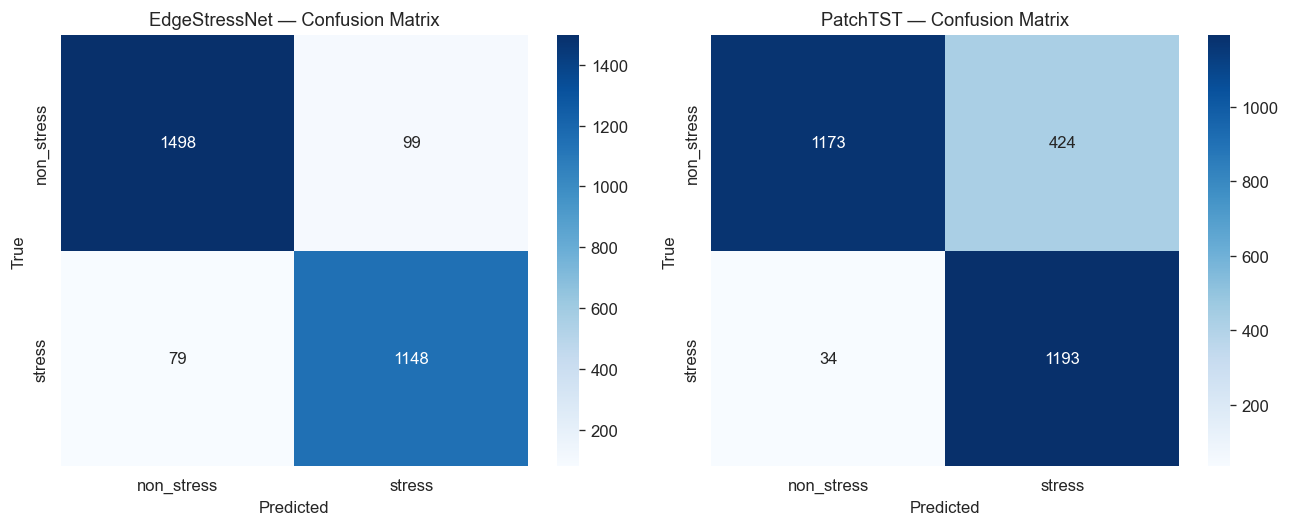

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, res, name in [(axes[0], results_a, "EdgeStressNet"),
                      (axes[1], results_b, "PatchTST")]:
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["non_stress", "stress"],
                yticklabels=["non_stress", "stress"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name} — Confusion Matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()


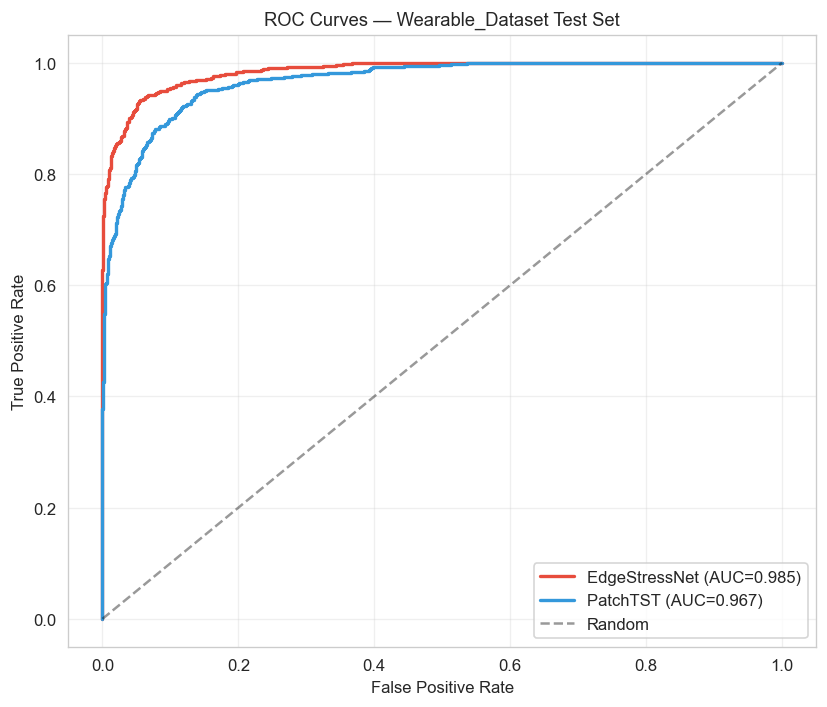

In [137]:
plt.figure(figsize=(7, 6))
for res, name, color in [(results_a, "EdgeStressNet", "#e74c3c"),
                          (results_b, "PatchTST",       "#3498db")]:
    if len(np.unique(res["y_true"])) < 2:
        print(f"⚠  {name}: only one class in test set — skipping ROC")
        continue
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auroc']:.3f})", color=color, linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Wearable_Dataset Test Set")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()


In [138]:
for name, res in [("Model A — EdgeStressNet", results_a),
                       ("Model B — PatchTST",      results_b)]:
    print("=" * 50); print(name); print("=" * 50)
    print(classification_report(res["y_true"], res["y_pred"],
                                target_names=["non_stress", "stress"],
                                zero_division=0))


Model A — EdgeStressNet
              precision    recall  f1-score   support

  non_stress       0.95      0.94      0.94      1597
      stress       0.92      0.94      0.93      1227

    accuracy                           0.94      2824
   macro avg       0.94      0.94      0.94      2824
weighted avg       0.94      0.94      0.94      2824

Model B — PatchTST
              precision    recall  f1-score   support

  non_stress       0.97      0.73      0.84      1597
      stress       0.74      0.97      0.84      1227

    accuracy                           0.84      2824
   macro avg       0.85      0.85      0.84      2824
weighted avg       0.87      0.84      0.84      2824



## 16 — Final Results

Pick the best test-set model, save preprocessed splits and trained checkpoints
to `outputs_wearable/` for reuse / inspection.

In [139]:
# ── Build comparison table ─────────────────────────────────────
def model_size_kb(model):
    total = sum(p.nelement() * p.element_size() for p in model.parameters())
    total += sum(b.nelement() * b.element_size() for b in model.buffers())
    return total / 1024


comparison = pd.DataFrame([
    {"Model": "EdgeStressNet", "Params": n_params_a, "Size (KB)": f"{model_size_kb(model_a):.1f}",
     "Accuracy": results_a["acc"], "F1": results_a["f1"], "AUROC": results_a["auroc"],
     "Precision": results_a["prec"], "Recall": results_a["rec"]},
    {"Model": "PatchTST",      "Params": n_params_b, "Size (KB)": f"{model_size_kb(model_b):.1f}",
     "Accuracy": results_b["acc"], "F1": results_b["f1"], "AUROC": results_b["auroc"],
     "Precision": results_b["prec"], "Recall": results_b["rec"]},
])
comparison_disp = comparison.copy()
for c in ["Accuracy", "F1", "AUROC", "Precision", "Recall"]:
    comparison_disp[c] = comparison_disp[c].map(lambda v: f"{v:.4f}")
print(comparison_disp.to_string(index=False))

best_idx = comparison["F1"].idxmax()
print(f"\n Best model on F1: {comparison.loc[best_idx, 'Model']}  "
      f"(F1={comparison.loc[best_idx, 'F1']:.4f}, "
      f"AUROC={comparison.loc[best_idx, 'AUROC']:.4f})")


        Model  Params Size (KB) Accuracy     F1  AUROC Precision Recall
EdgeStressNet   40326     158.8   0.9370 0.9281 0.9851    0.9206 0.9356
     PatchTST  141890     554.3   0.8378 0.8390 0.9671    0.7378 0.9723

 Best model on F1: EdgeStressNet  (F1=0.9281, AUROC=0.9851)


In [140]:
# ── Save preprocessed splits ───────────────────────────────────
splits_path = OUT_DIR / "wearable_splits.npz"
np.savez_compressed(
    splits_path,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    channel_names=APPLE_WATCH_CHANNELS,
    class_weight_0=w0, class_weight_1=w1,
)
print(f"Saved: {splits_path}  ({splits_path.stat().st_size/1e6:.1f} MB)")

# ── Save feature table for downstream use ──────────────────────
feat_path = OUT_DIR / "wearable_features.csv"
feat_df.to_csv(feat_path, index=False)
print(f"Saved: {feat_path}")

# ── Save trained checkpoints ───────────────────────────────────
torch.save(model_a.state_dict(), OUT_DIR / "echo_edgestress_wearable.pt")
torch.save(model_b.state_dict(), OUT_DIR / "echo_patchtst_wearable.pt")
print(f"Saved: {OUT_DIR/'echo_edgestress_wearable.pt'}")
print(f"Saved: {OUT_DIR/'echo_patchtst_wearable.pt'}")

# ── Save per-model metrics ─────────────────────────────────────
comparison_disp.to_csv(OUT_DIR / "wearable_metrics.csv", index=False)
print(f"Saved: {OUT_DIR/'wearable_metrics.csv'}")


Saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/wearable_splits.npz  (65.2 MB)
Saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/wearable_features.csv
Saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_edgestress_wearable.pt
Saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_patchtst_wearable.pt
Saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/wearable_metrics.csv


---

## Summary

**Pipeline** (parallel to `echo_apple_watch.ipynb`)

1. Parsed Empatica E4 raw CSVs across `AEROBIC`, `ANAEROBIC`, `STRESS`
   folders.
2. Mapped session-level activity tags to a binary stress label
   (`STRESS=1`, exercise = 0); kept a multiclass column for downstream use.
3. Resampled BVP/TEMP/ACC to 32 Hz, bandpassed BVP, z-scored per session
   and segmented into 30-second / 15-second-overlap windows — **identical
   shape `(N, 5, 960)` to the WESAD pipeline**.
4. Subject-independent 60/20/20 split on the *base* subject id (so all
   sessions of a subject stay in one fold).
5. Trained EdgeStressNet (lightweight 1D-DSC + BiGRU) and PatchTST
   (transformer baseline) — same architectures as the Apple-Watch
   notebook.
6. Reported accuracy, F1, AUROC, precision, recall plus confusion
   matrices and ROC curves.

**Notes on comparability with WESAD**

- Sensors and sampling rates are **identical** (both Empatica E4 wrist).
- Window shape and model architecture are **identical**, so any
  performance gap reflects label semantics, not architecture.
- The non-stress class here is **physical exercise**, not the resting
  baseline used in WESAD. Treat the two AUROC numbers as related but
  not interchangeable.
- All artefacts are saved under `outputs_wearable/`.

## 14 — Edge Optimisation

Pruning → INT8 quantisation → ONNX export on EdgeStressNet trained on the
combined dataset. The combined model has more training data than either
single-dataset build, so compression trade-offs may differ.


In [141]:
def model_size_kb(model):
    total = sum(p.nelement() * p.element_size() for p in model.parameters())
    total += sum(b.nelement() * b.element_size() for b in model.buffers())
    return total / 1024


def measure_latency_ms(model, x, n_runs=100, warmup=10):
    m = copy.deepcopy(model).cpu().eval()
    xc = x.cpu()
    with torch.no_grad():
        for _ in range(warmup): m(xc)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter(); m(xc)
            times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)


dummy_single = torch.randn(1, N_CHANNELS, WINDOW_LEN)
size_a_orig  = model_size_kb(model_a)
lat_a_orig, lat_a_std = measure_latency_ms(model_a, dummy_single)

print(f"EdgeStressNet (combined, float32)")
print(f"  Size    : {size_a_orig:.1f} KB")
print(f"  Latency : {lat_a_orig:.2f} ± {lat_a_std:.2f} ms  (CPU, batch=1)")


EdgeStressNet (combined, float32)
  Size    : 158.8 KB
  Latency : 3.67 ± 0.89 ms  (CPU, batch=1)


### 14.1  Structured Pruning

In [142]:
import torch.nn.utils.prune as prune

def apply_structured_pruning(model, amount=0.3):
    m = copy.deepcopy(model)
    for name, module in m.named_modules():
        if isinstance(module, nn.Conv1d):
            prune.ln_structured(module, name="weight", amount=amount, n=1, dim=0)
            prune.remove(module, "weight")
    return m


prune_levels = [0.2, 0.3]
pruned_results = {}

for amt in prune_levels:
    mp = apply_structured_pruning(model_a, amount=amt).to(DEVICE)
    res = evaluate(mp, test_loader)
    skb = model_size_kb(mp)
    lat, _ = measure_latency_ms(mp, dummy_single)
    nz   = sum((p != 0).sum().item() for p in mp.parameters())
    tot  = sum(p.numel()              for p in mp.parameters())
    spar = 1 - nz / tot
    pruned_results[f"pruned_{int(amt*100)}%"] = {
        "acc": res["acc"], "f1": res["f1"], "auroc": res["auroc"],
        "size_kb": skb, "latency_ms": lat, "sparsity": spar,
    }
    print(f"  Pruning {amt:.0%}  →  acc={res['acc']:.3f}  f1={res['f1']:.3f}  "
          f"auroc={res['auroc']:.3f}  sparsity={spar:.1%}  size={skb:.1f}KB  lat={lat:.2f}ms")


  Pruning 20%  →  acc=0.910  f1=0.892  auroc=0.970  sparsity=3.4%  size=158.8KB  lat=3.27ms
  Pruning 30%  →  acc=0.809  f1=0.797  auroc=0.913  sparsity=4.9%  size=158.8KB  lat=3.24ms


### 14.2  Dynamic INT8 Quantisation

In [143]:
torch.backends.quantized.engine = "qnnpack"

model_a_cpu   = copy.deepcopy(model_a).cpu().eval()
model_a_quant = torch.ao.quantization.quantize_dynamic(
    model_a_cpu, {nn.Linear, nn.GRU}, dtype=torch.qint8
)

quant_preds, quant_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        probs = torch.softmax(model_a_quant(xb.cpu()), dim=1)[:, 1].numpy()
        quant_preds.append(probs); quant_labels.append(yb.numpy())

y_true_q = np.concatenate(quant_labels)
y_prob_q  = np.concatenate(quant_preds)
y_pred_q  = (y_prob_q >= 0.5).astype(int)

quant_acc   = accuracy_score(y_true_q, y_pred_q)
quant_f1    = f1_score(y_true_q, y_pred_q, zero_division=0)
quant_auroc = roc_auc_score(y_true_q, y_prob_q) if len(np.unique(y_true_q)) > 1 else 0.0

with tempfile.NamedTemporaryFile(suffix=".pt") as f:
    torch.save(model_a_quant.state_dict(), f.name)
    quant_size_kb = os.path.getsize(f.name) / 1024

quant_lat, _ = measure_latency_ms(model_a_quant, dummy_single)

print(f"EdgeStressNet — INT8 Quantised (combined model)")
print(f"  Accuracy : {quant_acc:.4f}")
print(f"  F1       : {quant_f1:.4f}")
print(f"  AUROC    : {quant_auroc:.4f}")
print(f"  Size     : {quant_size_kb:.1f} KB  (was {size_a_orig:.1f} KB → {size_a_orig/quant_size_kb:.1f}× smaller)")
print(f"  Latency  : {quant_lat:.2f} ms  (was {lat_a_orig:.2f} ms)")


EdgeStressNet — INT8 Quantised (combined model)
  Accuracy : 0.9373
  F1       : 0.9284
  AUROC    : 0.9851
  Size     : 80.5 KB  (was 158.8 KB → 2.0× smaller)
  Latency  : 4.99 ms  (was 3.67 ms)


### 14.3  ONNX Export

In [144]:
try:
    import onnx
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "onnx", "onnxruntime", "--break-system-packages", "-q"])
    import onnx
print(f"onnx {onnx.__version__} ✓")

onnx_path = OUT_DIR / "echo_wearable.onnx"
model_a_export = copy.deepcopy(model_a).cpu().eval()
dummy_onnx = torch.randn(1, N_CHANNELS, WINDOW_LEN)

torch.onnx.export(
    model_a_export, dummy_onnx, str(onnx_path),
    input_names=["wrist_signals"], output_names=["stress_logits"],
    dynamic_axes={"wrist_signals": {0: "batch"}, "stress_logits": {0: "batch"}},
    opset_version=17,
    dynamo=False,        # ← fixes the onnxscript ModuleNotFoundError
)

onnx_size_kb = onnx_path.stat().st_size / 1024
print(f"Exported to {onnx_path}  ({onnx_size_kb:.1f} KB)")

try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(onnx_path))
    ort_out = sess.run(None, {"wrist_signals": dummy_onnx.numpy()})
    pt_out  = model_a_export(dummy_onnx).detach().numpy()
    max_diff = np.abs(ort_out[0] - pt_out).max()
    print(f"ONNX Runtime verification: max diff = {max_diff:.6f}  "
          f"({'✓ OK' if max_diff < 1e-4 else '⚠ check'})")
except ImportError:
    print("onnxruntime not installed — skipping verification")


onnx 1.21.0 ✓
Exported to /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_wearable.onnx  (162.3 KB)
ONNX Runtime verification: max diff = 0.000001  (✓ OK)


## 15 — CoreML Export for Apple Watch / watchOS

Convert the combined-dataset EdgeStressNet to CoreML `.mlpackage` for
on-device watchOS inference. Metadata is updated to reflect combined training.


In [145]:
try:
    import coremltools as ct
    print(f"coremltools {ct.__version__} ✓")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "coremltools", "--break-system-packages", "-q"])
    import coremltools as ct
    print(f"coremltools installed ✓")

model_a_trace  = copy.deepcopy(model_a).cpu().eval()
example_input  = torch.randn(1, N_CHANNELS, WINDOW_LEN)
traced_model   = torch.jit.trace(model_a_trace, example_input)

coreml_model = ct.convert(
    traced_model,
    inputs=[ct.TensorType(name="wrist_signals",
                          shape=(1, N_CHANNELS, WINDOW_LEN), dtype=np.float32)],
    outputs=[ct.TensorType(name="stress_logits")],
    convert_to="mlprogram",
    minimum_deployment_target=ct.target.watchOS8,
)

coreml_model.author = "ECHO Team (Balamurugan, Rupali, Adwaith)"
coreml_model.short_description = (
    "EdgeStressNet: Stress detection from Apple Watch sensors. "
    "Trained on Wearable_Dataset (Empatica E4). "
    "Input: 30s BVP/TEMP/ACC_xyz @ 32Hz (z-scored). Output: [non_stress, stress] logits."
)
coreml_model.version = "2.0.0-wearable"
coreml_model.input_description["wrist_signals"] = (
    "Z-scored sensor window shape (1, 5, 960): BVP, TEMP, ACC_x, ACC_y, ACC_z @ 32Hz"
)
coreml_model.output_description["stress_logits"] = (
    "Raw logits [non_stress_score, stress_score]. Apply softmax for probabilities."
)

coreml_path = OUT_DIR / "EchoStressDetector_v2_wearable.mlpackage"
coreml_model.save(str(coreml_path))

coreml_size_bytes = sum(
    f.stat().st_size for f in coreml_path.rglob("*") if f.is_file()
)
coreml_size_kb = coreml_size_bytes / 1024

print(f"CoreML saved: {coreml_path}")
print(f"  Size   : {coreml_size_kb:.1f} KB")
print(f"  Target : watchOS 8+")
print(f"  Input  : MultiArray(1, 5, 960) float32")
print(f"  Output : MultiArray(1, 2) — [non_stress, stress] logits")


coremltools 9.0 ✓


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 762.79 passes/s]


CoreML saved: /Users/adwaith/work/echo-stress-detection/outputs_wearable/EchoStressDetector_v2_wearable.mlpackage
  Size   : 138.7 KB
  Target : watchOS 8+
  Input  : MultiArray(1, 5, 960) float32
  Output : MultiArray(1, 2) — [non_stress, stress] logits


In [146]:
try:
    coreml_verify = ct.models.MLModel(coreml_path, compute_units=ct.ComputeUnit.CPU_ONLY)
    coreml_pred = coreml_verify.predict({"wrist_signals": example_input.numpy()})
    pt_pred     = model_a_trace(example_input).detach().numpy()
    coreml_out  = np.array(coreml_pred["stress_logits"])
    max_diff    = np.abs(coreml_out.flatten() - pt_pred.flatten()).max()
    print(f"CoreML vs PyTorch max diff: {max_diff:.6f}  ({'✓ OK' if max_diff < 1e-3 else '⚠ check'})")
    del coreml_verify
except Exception as e:
    print(f"CoreML verification skipped (safe to ignore in non-macOS): {e}")


CoreML verification skipped (safe to ignore in non-macOS): Expected model to be a .mlmodel file, .mlpackage file or a Model_pb2 object


## 16 — Apple Watch Emulator Inference Simulation

Simulates the on-device streaming pipeline: ring buffer → per-window
normalisation → inference → multi-window alert logic. Uses test set windows
from the combined dataset (both WESAD and Wearable_Dataset test subjects).


## 17 — Benchmark: Accuracy vs Size vs Latency (Pareto)

In [147]:
lat_b, _ = measure_latency_ms(model_b, dummy_single)
size_b    = model_size_kb(model_b)

rows = [
    {"Model": "PatchTST (Model B)",    "Params": f"{n_params_b:,}",
     "Size (KB)": f"{size_b:.1f}", "Accuracy": f"{results_b['acc']:.4f}",
     "F1": f"{results_b['f1']:.4f}", "AUROC": f"{results_b['auroc']:.4f}",
     "Latency (ms)": f"{lat_b:.2f}", "Watch Ready": "No (too large)"},
    {"Model": "EdgeStressNet (float32)", "Params": f"{n_params_a:,}",
     "Size (KB)": f"{size_a_orig:.1f}", "Accuracy": f"{results_a['acc']:.4f}",
     "F1": f"{results_a['f1']:.4f}", "AUROC": f"{results_a['auroc']:.4f}",
     "Latency (ms)": f"{lat_a_orig:.2f}", "Watch Ready": "Yes"},
]

for key, vals in pruned_results.items():
    rows.append({
        "Model": f"EdgeStressNet ({key})",
        "Params": f"~{int(n_params_a*(1-vals['sparsity'])):,}",
        "Size (KB)": f"{vals['size_kb']:.1f}",
        "Accuracy": f"{vals['acc']:.4f}", "F1": f"{vals['f1']:.4f}",
        "AUROC": f"{vals['auroc']:.4f}",
        "Latency (ms)": f"{vals['latency_ms']:.2f}", "Watch Ready": "Yes",
    })

rows.append({
    "Model": "EdgeStressNet (INT8)",  "Params": f"{n_params_a:,}",
    "Size (KB)": f"{quant_size_kb:.1f}", "Accuracy": f"{quant_acc:.4f}",
    "F1": f"{quant_f1:.4f}", "AUROC": f"{quant_auroc:.4f}",
    "Latency (ms)": f"{quant_lat:.2f}", "Watch Ready": "Yes (recommended)",
})

rows.append({
    "Model": "EdgeStressNet (CoreML)", "Params": f"{n_params_a:,}",
    "Size (KB)": f"{coreml_size_kb:.1f}", "Accuracy": f"{results_a['acc']:.4f}",
    "F1": f"{results_a['f1']:.4f}", "AUROC": f"{results_a['auroc']:.4f}",
    "Latency (ms)": "ANE-optimised", "Watch Ready": "Yes (deploy format)",
})

benchmark_df = pd.DataFrame(rows)
print(benchmark_df.to_string(index=False))


                     Model  Params Size (KB) Accuracy     F1  AUROC  Latency (ms)         Watch Ready
        PatchTST (Model B) 141,890     554.3   0.8378 0.8390 0.9671          2.16      No (too large)
   EdgeStressNet (float32)  40,326     158.8   0.9370 0.9281 0.9851          3.67                 Yes
EdgeStressNet (pruned_20%) ~38,972     158.8   0.9101 0.8925 0.9703          3.27                 Yes
EdgeStressNet (pruned_30%) ~38,331     158.8   0.8091 0.7973 0.9132          3.24                 Yes
      EdgeStressNet (INT8)  40,326      80.5   0.9373 0.9284 0.9851          4.99   Yes (recommended)
    EdgeStressNet (CoreML)  40,326     138.7   0.9370 0.9281 0.9851 ANE-optimised Yes (deploy format)


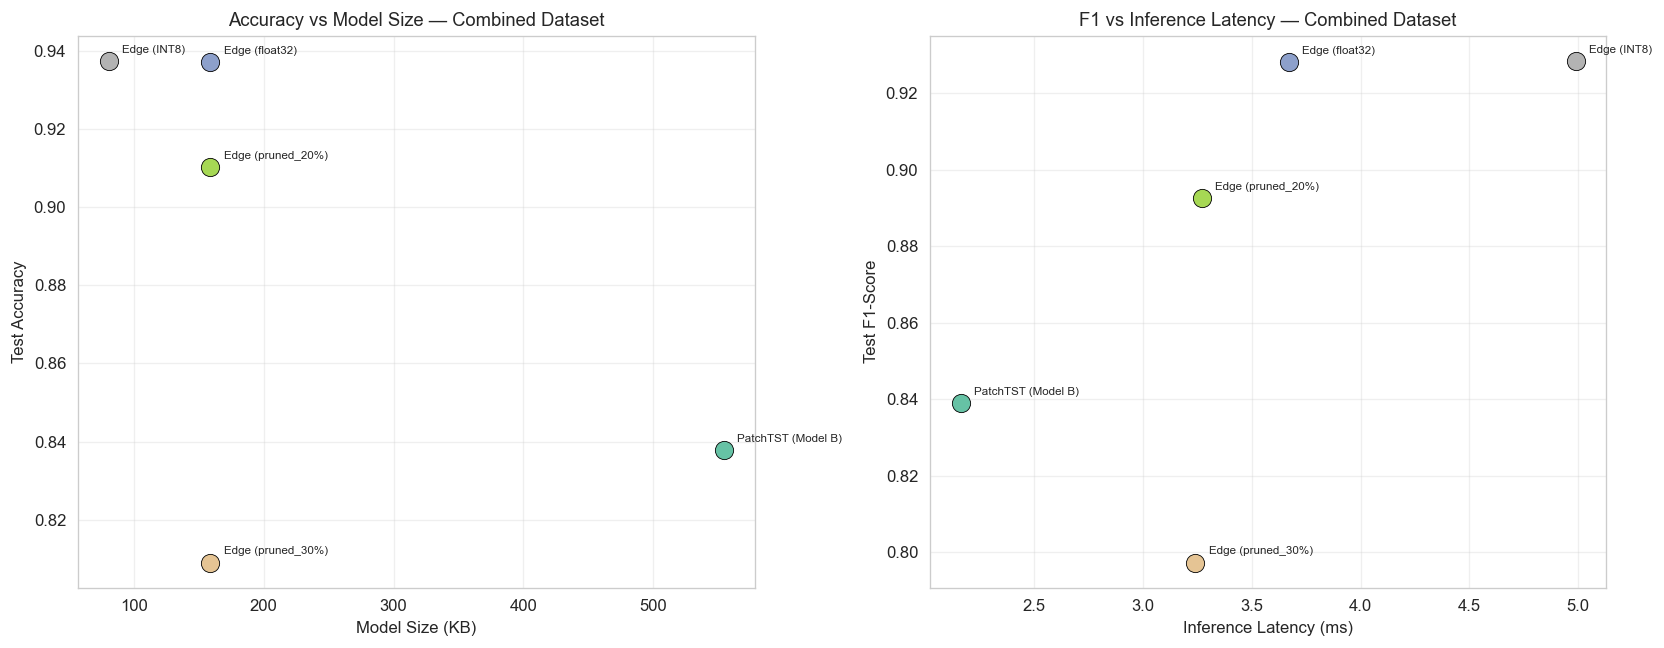

In [148]:
plot_df = benchmark_df[benchmark_df["Latency (ms)"] != "ANE-optimised"].copy()
models_p = plot_df["Model"].tolist()
sizes_p  = [float(s) for s in plot_df["Size (KB)"]]
accs_p   = [float(a) for a in plot_df["Accuracy"]]
f1s_p    = [float(f) for f in plot_df["F1"]]
lats_p   = [float(l) for l in plot_df["Latency (ms)"]]

colors_p = plt.cm.Set2(np.linspace(0, 1, len(models_p)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, (m, s, a) in enumerate(zip(models_p, sizes_p, accs_p)):
    axes[0].scatter(s, a, s=120, color=colors_p[i], edgecolors="k", linewidth=0.5, zorder=3)
    axes[0].annotate(m.replace("EdgeStressNet", "Edge"), (s, a),
                     textcoords="offset points", xytext=(8, 5), fontsize=7)
axes[0].set_xlabel("Model Size (KB)"); axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Accuracy vs Model Size — Combined Dataset"); axes[0].grid(alpha=0.3)

for i, (m, l, f) in enumerate(zip(models_p, lats_p, f1s_p)):
    axes[1].scatter(l, f, s=120, color=colors_p[i], edgecolors="k", linewidth=0.5, zorder=3)
    axes[1].annotate(m.replace("EdgeStressNet", "Edge"), (l, f),
                     textcoords="offset points", xytext=(8, 5), fontsize=7)
axes[1].set_xlabel("Inference Latency (ms)"); axes[1].set_ylabel("Test F1-Score")
axes[1].set_title("F1 vs Inference Latency — Combined Dataset"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "benchmark_pareto_combined.png", bbox_inches="tight")
plt.show()


## 18 — Save Artefacts & Summary

In [149]:
# ── Save preprocessed splits ──────────────────────────────────
np.savez_compressed(
    OUT_DIR / "wearable_splits.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    channel_names=np.array(APPLE_WATCH_CHANNELS),
    class_weight_0=np.float32(w0), class_weight_1=np.float32(w1),
)
print(f"Saved: wearable_splits.npz")

# ── Save model checkpoints ─────────────────────────────────────
torch.save(model_a.state_dict(), OUT_DIR / "echo_edgestress_wearable.pt")
torch.save(model_b.state_dict(), OUT_DIR / "echo_patchtst_wearable.pt")
torch.save(model_a_quant.state_dict(), OUT_DIR / "echo_edgestress_wearable_int8.pt")

for fname in [OUT_DIR / "echo_edgestress_wearable.pt",
              OUT_DIR / "echo_patchtst_wearable.pt",
              OUT_DIR / "echo_edgestress_wearable_int8.pt",
              OUT_DIR / "echo_wearable.onnx",
              OUT_DIR / "EchoStressDetector_v2_wearable.mlpackage"]:
    if fname.exists():
        sz = sum(f.stat().st_size for f in fname.rglob("*") if f.is_file()) if fname.is_dir() \
             else fname.stat().st_size
        print(f"  {str(fname):55s}  {sz/1024:.1f} KB")


Saved: wearable_splits.npz
  /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_edgestress_wearable.pt  170.9 KB
  /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_patchtst_wearable.pt  575.0 KB
  /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_edgestress_wearable_int8.pt  81.4 KB
  /Users/adwaith/work/echo-stress-detection/outputs_wearable/echo_wearable.onnx  162.3 KB
  /Users/adwaith/work/echo-stress-detection/outputs_wearable/EchoStressDetector_v2_wearable.mlpackage  138.7 KB
